# Image caption generation

This project uses a subset of the [COCO "Common Objects in Context" dataset](https://cocodataset.org/) for image caption generation. COCO contains 330K images, of 80 object categories, and at least five textual reference captions per image. The subset used in this project contains 5029 of these images, each of which has five or more different descriptions of the salient entities and activities, and I refer to it as COCO_5029.

Google colab was used to undertake this project.

I build an image-to-text model, where an Encoder network encodes the input image as a feature vector by providing the outputs of the last fully connected layer of a pre-trained CNN (I use [ResNet-152](https://arxiv.org/abs/1512.03385)). This pretrained network was trained on the complete ImageNet dataset and is thus able to recognise common objects. These features are then fed into a Decoder network along with the reference captions. As the image feature dimensions are large and sparse, the Decoder network includes a linear layer which downsizes them, followed by a batch normalisation layer to speed up training. The resulting features, as well as the reference text captions, are passed into an RNN. The reference captions used to compute loss are represented as numerical vectors via an embedding layer whose weights are learned during training.

## Notebook Organization

> 1. Extracting image features
> 2. Text preparation
> 3. Train DecoderRNN
> 4. Generate predictions on test data
> 5. Caption length statistics and analysis
> 6. Caption evaluation using BLEU score
> 7. Caption evaluation using cosine similarity
> 8. Comparing BLEU and cosine similarity

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Imports

In [3]:
import zipfile
import torch
import torch.nn as nn
from torchvision import transforms
import torchvision.models as models
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from PIL import Image
from IPython.display import display
import json
import random
from torch.nn.functional import log_softmax, cosine_similarity
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

In [4]:
#setting a seed for random and torch to ensure reproducibility
seed = 0

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

#ensuring determinism for GPU
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [5]:
#extract images
zip_path = '/content/drive/MyDrive/Colab Notebooks/coco_subset_images.zip'
extract_path = '/content/coco_subset_images/'
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [6]:
#extract annotations
zip_path = '/content/drive/MyDrive/Colab Notebooks/annotations_trainval2017.zip'
extract_path = '/content/annotations_trainval2017/'
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [7]:
#detect available device (CPU/GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 1 Extracting image features

### 1.1 EncoderCNN


In [9]:
#print the last layer of resnet-152 to see what it is
resnet152 = models.resnet152(weights=True)
last_layer = list(resnet152.children())[-1]
print(last_layer)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:01<00:00, 180MB/s]


Linear(in_features=2048, out_features=1000, bias=True)


In [10]:
class EncoderCNN(nn.Module):
    def __init__(self):
        """Load the pretrained ResNet-152 and remove the last fully connected (fc) layer."""
        super(EncoderCNN, self).__init__()

        #load the pretrained ResNet-152
        resnet152 = models.resnet152(weights=True)

        #remove the last fully connected (fc) layer
        self.resnet = nn.Sequential(*(list(resnet152.children())[:-1]))

    def forward(self, images):
        """Extract feature vectors from input images."""
        with torch.no_grad():
            features = self.resnet(images)
        return features

In [11]:
#instantiate encoder and put it into evaluation mode.
encoder = EncoderCNN().to(device)
encoder.eval()

EncoderCNN(
  (resnet): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64

### 1.2 Processing the images

In [12]:
#transform
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.Normalize((0.485, 0.456, 0.406),   # using ImageNet norms
                         (0.229, 0.224, 0.225))])

In [13]:
class CocoImages(Dataset):
    def __init__(self, folder, transform=None):
        """List of image filenames in folder."""
        self.folder = folder
        self.transform = transform
        self.images = [img for img in sorted(os.listdir(folder))] #sorted to avoid randomness

    def __getitem__(self, idx):
        """Return the transformed image and the image ID."""
        img_name = self.images[idx]
        path = os.path.join(self.folder, img_name)

        #Load images with PIL and convert to 3 channels (RGB)
        img = Image.open(path).convert('RGB')

        #Apply transform
        if self.transform:
            img = self.transform(img)

        #Return image ID without file extension
        img_id = os.path.splitext(img_name)[0]

        return img, img_id

    def __len__(self):
        """Return number of images."""
        return len(self.images)

In [14]:
path = '/content/coco_subset_images/coco_subset_images/images'

#create an instance of the Dataset class.
dataset = CocoImages(path, transform=data_transform)

In [15]:
#checking that I have got all the images
len(dataset)

5029

In [16]:
#checking what my dataset contains
img, img_id = dataset[0]
print(img.shape, img_id)

torch.Size([3, 224, 224]) 000000000009


In [17]:
#create the dataloader
dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

#dictionary for img_id:img_feature
img_features = {}

with torch.no_grad():
    for imgs, img_ids in dataloader:
        imgs = imgs.to(device)
        #forward pass
        features = encoder(imgs)
        features = features.squeeze() #flatten the output of the ResNet-152 encoder [2048, 1, 1] to [2048]
        for i, img_id in enumerate(img_ids):
            img_features[img_id] = features[i]

In [18]:
#check the length of this dictionary and the shape of one entry
print(len(img_features))
print(img_features['000000024823'].shape)

5029
torch.Size([2048])


In [19]:
#convert the keys of the dictionary to integers (without 0 padding)
img_features = {int(key): value for key, value in img_features.items()}
print(len(img_features))
print(img_features[24823].shape)

5029
torch.Size([2048])


## 2 Text preparation


### 2.1 Build the caption dataset

In [21]:
#loading the coco_subset_meta.csv file in a dataframe
path='/content/drive/MyDrive/Colab Notebooks/coco_subset_meta.csv'
coco_subset_meta = pd.read_csv(path)
coco_subset_meta.head()

,Unnamed: 0,license,file_name,coco_url,height,width,date_captured,flickr_url,id
0,0,2,000000262145.jpg,http://images.cocodataset.org/train2017/000000...,427,640,2013-11-20 02:07:55,http://farm8.staticflickr.com/7187/6967031859_...,262145
1,1,1,000000262146.jpg,http://images.cocodataset.org/train2017/000000...,640,480,2013-11-19 23:07:16,http://farm6.staticflickr.com/5090/5341741494_...,262146
2,2,3,000000524291.jpg,http://images.cocodataset.org/train2017/000000...,426,640,2013-11-18 09:59:07,http://farm2.staticflickr.com/1045/934293170_d...,524291
3,3,1,000000262148.jpg,http://images.cocodataset.org/train2017/000000...,512,640,2013-11-20 05:50:03,http://farm5.staticflickr.com/4028/4549977479_...,262148
4,4,3,000000393223.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-21 20:08:57,http://farm1.staticflickr.com/28/45521803_c5cb...,393223


In [22]:
#there are more than 5029 entries in this dataframe
coco_subset_meta.shape

(8000, 9)

In [23]:
#checking for duplicate ids
duplicate_id = coco_subset_meta['id'].duplicated()
duplicate_id.sum()

np.int64(2971)

In [24]:
#dropping duplicate ids
coco_subset_meta = coco_subset_meta.drop_duplicates(subset=['id'])
coco_subset_meta.shape

(5029, 9)

In [25]:
#opening the captions_train2017.json file
path = '/content/annotations_trainval2017/annotations_trainval2017/annotations/captions_train2017.json'
with open (path, 'r') as f:
    data = json.load(f) #this is a dictionary
print(data.keys())

dict_keys(['info', 'licenses', 'images', 'annotations'])


In [26]:
#create a dataframe from the list of dictionaries data['annotations']
annotations = pd.DataFrame(data['annotations'])
annotations.head()

,image_id,id,caption
0,203564,37,A bicycle replica with a clock as the front wh...
1,322141,49,A room with blue walls and a white sink and door.
2,16977,89,A car that seems to be parked illegally behind...
3,106140,98,A large passenger airplane flying through the ...
4,106140,101,There is a GOL plane taking off in a partly cl...


In [27]:
#merge the two above dataframes to obtain a dataframe that contains all the captions for the 5029 coco images
df_captions = pd.merge(annotations, coco_subset_meta, left_on='image_id', right_on='id', how='inner')
df_captions.shape #roughly 5 captions per image

(25154, 12)

In [28]:
#I keep only the necessary information
df_captions = df_captions[['image_id', 'caption', 'file_name']]
df_captions.head()

,image_id,caption,file_name
0,57429,An airplane with its landing wheels out landing.,000000057429.jpg
1,57429,A plane that is taking off at an airport,000000057429.jpg
2,57429,A man takes a picture of an airplane taking off.,000000057429.jpg
3,410627,The young man is stirring his pot of food with...,000000410627.jpg
4,554037,"a counter with vegetables, knife and cutting b...",000000554037.jpg


In [29]:
#quick check: most images have 5 captions, while 9 have 6 captions.
df_captions_grouped = df_captions.groupby('image_id').count()
df_captions_grouped['caption'].value_counts()

,count
caption,
5,5020
6,9


### 2.2 Clean the captions

In [30]:
def clean_caption(caption):
  """Make captions lowercase and containing only alphabet characters."""
  caption = ''.join(ch for ch in caption if (ch.isalpha() or ch.isspace()))
  return caption.lower()

In [31]:
#apply the above function to the caption column and create a new 'clean_caption' column
df_captions['clean_caption'] = df_captions['caption'].apply(clean_caption)
pd.set_option('display.max_colwidth', None)

#show the first 10 captions
df_captions[['caption', 'clean_caption']].head(10)

,caption,clean_caption
0,An airplane with its landing wheels out landing.,an airplane with its landing wheels out landing
1,A plane that is taking off at an airport,a plane that is taking off at an airport
2,A man takes a picture of an airplane taking off.,a man takes a picture of an airplane taking off
3,The young man is stirring his pot of food with a wooden spoon.,the young man is stirring his pot of food with a wooden spoon
4,"a counter with vegetables, knife and cutting board on it.",a counter with vegetables knife and cutting board on it
5,"asparragus, lemons and a bowl of rice on a counter top",asparragus lemons and a bowl of rice on a counter top
6,A large jet takes off from an airport runway.,a large jet takes off from an airport runway
7,A bathroom with a poster of an ugly face above the toilette.,a bathroom with a poster of an ugly face above the toilette
8,"The preparation of salmon, asparagus and lemons.",the preparation of salmon asparagus and lemons
9,A man enjoys cooking food in a pan,a man enjoys cooking food in a pan


### 2.3  Split the data

In [32]:
def split_ids(image_id_list, train=0.7, valid=0.1, test=0.2):
    """
    Args:
        image_id_list (list): List of unique image IDs.
        train (float): Proportion of the dataset to allocate for training.
        valid (float): Proportion of the dataset to allocate for validation.
        test (float): Proportion of the dataset to allocate for testing.
    Returns:
        tuple: Three lists containing IDs for the training, validation, and test sets.
    """

    num_items = len(image_id_list)
    train_size = int(train * num_items)
    valid_size = int(valid * num_items)
    test_size = num_items - train_size - valid_size

    #shuffle to ensure random split.
    image_id_list = image_id_list.copy()
    random.shuffle(image_id_list)

    train_ids = image_id_list[:train_size]
    valid_ids = image_id_list[train_size:train_size+valid_size]
    test_ids = image_id_list[-test_size:]

    return train_ids, valid_ids, test_ids

In [33]:
#get the unique image ids
image_id_list = df_captions['image_id'].unique().tolist()

#split them
train_ids, valid_ids, test_ids = split_ids(image_id_list)

#quick check that they sum up to the correct number
print(len(train_ids), len(valid_ids), len(test_ids), len(train_ids) + len(valid_ids) + len(test_ids))

3520 502 1007 5029


In [34]:
#define the three sets
train_set = df_captions[df_captions['image_id'].isin(train_ids)]
valid_set = df_captions[df_captions['image_id'].isin(valid_ids)]
test_set = df_captions[df_captions['image_id'].isin(test_ids)]

### 2.4 Building the vocabulary

In [35]:
class Vocabulary(object):
    """ Simple vocabulary wrapper which maps every unique word to an integer ID."""

    def __init__(self):
        #set both the IDs and words to dictionaries with special tokens
        self.word2idx = {'<pad>': 0, '<unk>': 1, '<end>': 2}
        self.idx2word = {0: '<pad>', 1: '<unk>', 2: '<end>'}
        self.idx = 3

    #add a word to the vocabulary
    def add_word(self, word):
      if word not in self.word2idx:
        self.word2idx[word] = self.idx
        self.idx2word[self.idx] = word
        self.idx += 1

    #retrieve the integer ID for a word. Return <unk>'s ID if the word is not found
    def __call__(self, word):
      if word in self.word2idx.keys():
        return self.word2idx[word]
      else:
        return self.word2idx['<unk>']

    def __len__(self):
        return len(self.word2idx)

In [36]:
#creat an instance of the Vocabulary() object and add all the words to it (ignoring words that appear 3 times or less)
coco_vocabulary = Vocabulary()

In [37]:
#concatenate the train and valid sets
train_valid_set = pd.concat([train_set, valid_set])

#create a temporary dictionary to keep track of word frequency
temp_dict={}

for index, caption in train_valid_set['clean_caption'].items():
  for word in caption.split():
    if word in temp_dict:
      temp_dict[word] += 1
    else:
      temp_dict[word] = 1

#remove words that appear 3 times or less
temp_dict_reduced = {word:freq for word, freq in temp_dict.items() if freq > 3}

#fill the coco_vocabulary
for word in temp_dict_reduced:
  coco_vocabulary.add_word(word)

#check the length
len(coco_vocabulary)

2390

### 2.5 The Dataset and DataLoader

In [38]:
class COCO_Subset(Dataset):
    """COCO subset custom dataset, compatible with torch.utils.data.DataLoader."""

    def __init__(self, df, features, vocab):
      """
        Args:
            df: dataframe
            features: image features
            vocab: vocabulary wrapper
        """
      self.df = df.reset_index(drop=True)
      self.features = features
      self.vocab = vocab

    def __getitem__(self, index):
        """Returns one data tuple (feature [1, 2048], target caption of word IDs [1, 47], and integer true caption length)."""

        #get the df row corresponding to index
        row = self.df.iloc[index]
        #get the corresponding image_id
        image_id = row['image_id']

        #feature tensor
        feature = self.features[image_id].unsqueeze(0)  #shape: [1, 2048]

        #caption tokenization
        caption = row['clean_caption']
        tokenized_caption = [self.vocab(word) for word in caption.split()]
        tokenized_caption.append(self.vocab.word2idx['<end>'])

        #true caption length
        true_caption_length = len(tokenized_caption)
        true_caption_length = torch.tensor(true_caption_length, dtype=torch.long)

        #final caption (with padding)
        max_len = 47
        while len(tokenized_caption) < max_len:
          tokenized_caption.append(self.vocab.word2idx['<pad>'])
        tokenized_caption = torch.tensor(tokenized_caption, dtype=torch.long)

        return feature, tokenized_caption, true_caption_length

    def __len__(self):
        return len(self.df)

In [39]:
#create the three datasets
train_dataset = COCO_Subset(train_set, img_features, coco_vocabulary)
valid_dataset = COCO_Subset(valid_set, img_features, coco_vocabulary)
test_dataset = COCO_Subset(test_set, img_features, coco_vocabulary)

In [40]:
#quick sanity check
len(train_dataset), len(train_set)

(17608, 17608)

In [41]:
#another quick sanity check
feature, caption, length = train_dataset[0]
feature, feature.shape, caption, len(caption), length

(tensor([[0.3178, 0.9797, 0.2677,  ..., 0.6220, 0.3038, 0.5410]],
        device='cuda:0'),
 torch.Size([1, 2048]),
 tensor([ 3,  4,  5,  3,  6,  7,  8,  1,  9, 10, 11,  1,  2,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]),
 47,
 tensor(13))

In [42]:
#create the three dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [43]:
#Load one batch of the training set and print out the shape of each returned Tensor.
train_iter = iter(train_loader)
features, captions, lengths = next(train_iter)
print(features.shape)
print(captions.shape)
print(lengths.shape)

torch.Size([64, 1, 2048])
torch.Size([64, 47])
torch.Size([64])


## 3 Train DecoderRNN

### 3.1 Define the decoder model

In [44]:
class DecoderRNN(nn.Module):
    def __init__(self, input_size, vocab_size, rnn_type='LSTM', embed_size=256, hidden_size=512, num_layers=1, max_seq_length=47):
        """
        Initialize the DecoderRNN.
        Inputs:
        - input_size: Size of the input image feature vector
        - vocab_size: Size of the vocabulary (number of unique words in captions)
        - rnn_type: Type of network used (RNN or LSTM)
        - embed_size: Dimensionality of word embeddings
        - hidden_size: Size of the RNN's hidden state
        - num_layers: Number of layers in the RNN
        - max_seq_length: Maximum length of the generated captions
        """
        super(DecoderRNN, self).__init__()
        self.input_size = input_size
        self.vocab_size = vocab_size
        self.rnn_type = rnn_type.upper()
        self.embed_size = embed_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.max_seq_length = max_seq_length

        #linear layer: the output dimension matches the RNN hidden state size
        self.linear1 = nn.Linear(self.input_size, self.hidden_size)

        #batch normalization layer
        self.bn = nn.BatchNorm1d(num_features=self.hidden_size)

        #linear layer: the output dimension matches the embedding size (to allow concatenation of image features and word embeddings later)
        self.linear2 = nn.Linear(self.hidden_size, self.embed_size)

        #embedding layer
        self.embedding = nn.Embedding(num_embeddings=self.vocab_size, embedding_dim=self.embed_size)

        #RNN architecture: I experimented both with Vanilla RNN and LSTM
        if self.rnn_type == 'LSTM':
          self.rnn = nn.LSTM(input_size=self.embed_size, hidden_size=self.hidden_size, num_layers=self.num_layers, batch_first=True)

        elif self.rnn_type == 'RNN':
          self.rnn = nn.RNN(input_size=self.embed_size, hidden_size=self.hidden_size, num_layers=self.num_layers, batch_first=True)

        #linear layer: raw confidence values over the vocabulary
        self.linear3 = nn.Linear(self.hidden_size, self.vocab_size)


    def forward(self, features, captions, lengths):
        """
        Decode image feature vectors and generate captions.
        Inputs:
        - features: Image features extracted from the EncoderCNN.
        - captions: Padded tokenized captions.
        - lengths: Actual lengths of captions before padding.
        Outputs:
        - outputs: Vocabulary predictions for each time step.
        """

        # STEP 1: Transform the image features using the Linear + BN layer
        features = features.squeeze(1) #shape [64, 2048]
        im_features = self.linear1(features) #shape [64, 512]
        im_features = self.bn(im_features) #shape [64, 512]
        im_features = self.linear2(im_features) #shape [64, 256]

        # STEP 2: Convert captions to embeddings
        embeddings = self.embedding(captions) #shape [64, 47, 256]

        # STEP 3: Concatenate image features and word embeddings
        im_features = im_features.unsqueeze(1) #shape [64, 1, 256]
        embeddings = torch.cat((im_features, embeddings), dim=1) #shape [64, 48, 256]

        # STEP 4: create a variable called `packed` that the RNN will process in the next step
        lengths = [length + 1 for length in lengths] #to account for the added image feature
        packed = pack_padded_sequence(embeddings, lengths, batch_first=True, enforce_sorted=False)

        # STEP 5: Processing the packed sequences with the RNN
        output_packed, hiddens = self.rnn(packed)

        # STEP 6: Transform the hidden states to output vocabulary probabilities
        outputs = self.linear3(output_packed.data)

        return outputs

In [45]:
#define different decoders for different architectures
architectures = [
    {'name': 'RNN_128_256', 'rnn_type': 'RNN', 'embed_size': 128, 'hidden_size': 256},
    {'name': 'RNN_256_512', 'rnn_type': 'RNN', 'embed_size': 256, 'hidden_size': 512},
    {'name': 'LSTM_128_256', 'rnn_type': 'LSTM', 'embed_size': 128, 'hidden_size': 256},
    {'name': 'LSTM_256_512', 'rnn_type': 'LSTM', 'embed_size': 256, 'hidden_size': 512},
]

### 3.2 Train the decoder

In [46]:
training_results = {}

for arch in architectures:

  #reset the seeds to ensure that all architectures start with the same initial conditions
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

  #instantiate the decoder
  decoder = DecoderRNN(2048, len(coco_vocabulary), rnn_type=arch['rnn_type'], embed_size=arch['embed_size'], hidden_size=arch['hidden_size']).to(device)

  #training
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(decoder.parameters())

  num_epochs = 20

  train_losses = []
  valid_losses = []

  for epoch in range(num_epochs):
    #set the decoder in training mode
    decoder.train()

    train_running_loss = 0.0
    valid_running_loss = 0.0

    for features, captions, lengths in train_loader:
      features, captions = features.to(device), captions.to(device)

      #zero the parameter gradients
      optimizer.zero_grad()

      #forward pass
      outputs = decoder(features, captions[:, :-1], lengths-1) #shortened the captions and lengths to match with label sizes when calculating loss

      #pack the labels
      labels = pack_padded_sequence(captions, lengths, batch_first=True, enforce_sorted=False)
      labels = labels.data

      #calculate the loss of the current batch
      loss = criterion(outputs, labels)

      #backward pass and optimize
      loss.backward()
      optimizer.step()

      #calculate training running loss
      train_running_loss += loss.item() * features.size(0) #Total batch loss = average batch loss * batch size

    #calculate training loss for each epoch
    train_loss = train_running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    #set the decoder in evaluation mode
    decoder.eval()
    with torch.no_grad():
      for features, captions, lengths in valid_loader:
        features, captions = features.to(device), captions.to(device)

        outputs = decoder(features, captions[:, :-1], lengths-1)

        labels = pack_padded_sequence(captions, lengths, batch_first=True, enforce_sorted=False)
        labels=labels.data

        loss = criterion(outputs, labels)
        valid_running_loss += loss.item() * features.size(0)

    #calculate validation loss for each epoch
    valid_loss = valid_running_loss / len(valid_loader.dataset)
    valid_losses.append(valid_loss)

    #print losses
    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

  #store network parameters and losses
  training_results[arch['name']] = {'state_dict': decoder.state_dict(), 'train_losses': train_losses, 'valid_losses': valid_losses}

Epoch [1/20], Training Loss: 4.5318, Validation Loss: 3.8144
Epoch [2/20], Training Loss: 3.4775, Validation Loss: 3.4128
Epoch [3/20], Training Loss: 3.1201, Validation Loss: 3.2248
Epoch [4/20], Training Loss: 2.9052, Validation Loss: 3.1413
Epoch [5/20], Training Loss: 2.7489, Validation Loss: 3.0958
Epoch [6/20], Training Loss: 2.6273, Validation Loss: 3.0523
Epoch [7/20], Training Loss: 2.5223, Validation Loss: 3.0384
Epoch [8/20], Training Loss: 2.4331, Validation Loss: 3.0194
Epoch [9/20], Training Loss: 2.3535, Validation Loss: 3.0344
Epoch [10/20], Training Loss: 2.2836, Validation Loss: 3.0386
Epoch [11/20], Training Loss: 2.2167, Validation Loss: 3.0510
Epoch [12/20], Training Loss: 2.1544, Validation Loss: 3.0571
Epoch [13/20], Training Loss: 2.0999, Validation Loss: 3.0906
Epoch [14/20], Training Loss: 2.0465, Validation Loss: 3.0990
Epoch [15/20], Training Loss: 1.9920, Validation Loss: 3.1128
Epoch [16/20], Training Loss: 1.9469, Validation Loss: 3.1346
Epoch [17/20], Tr

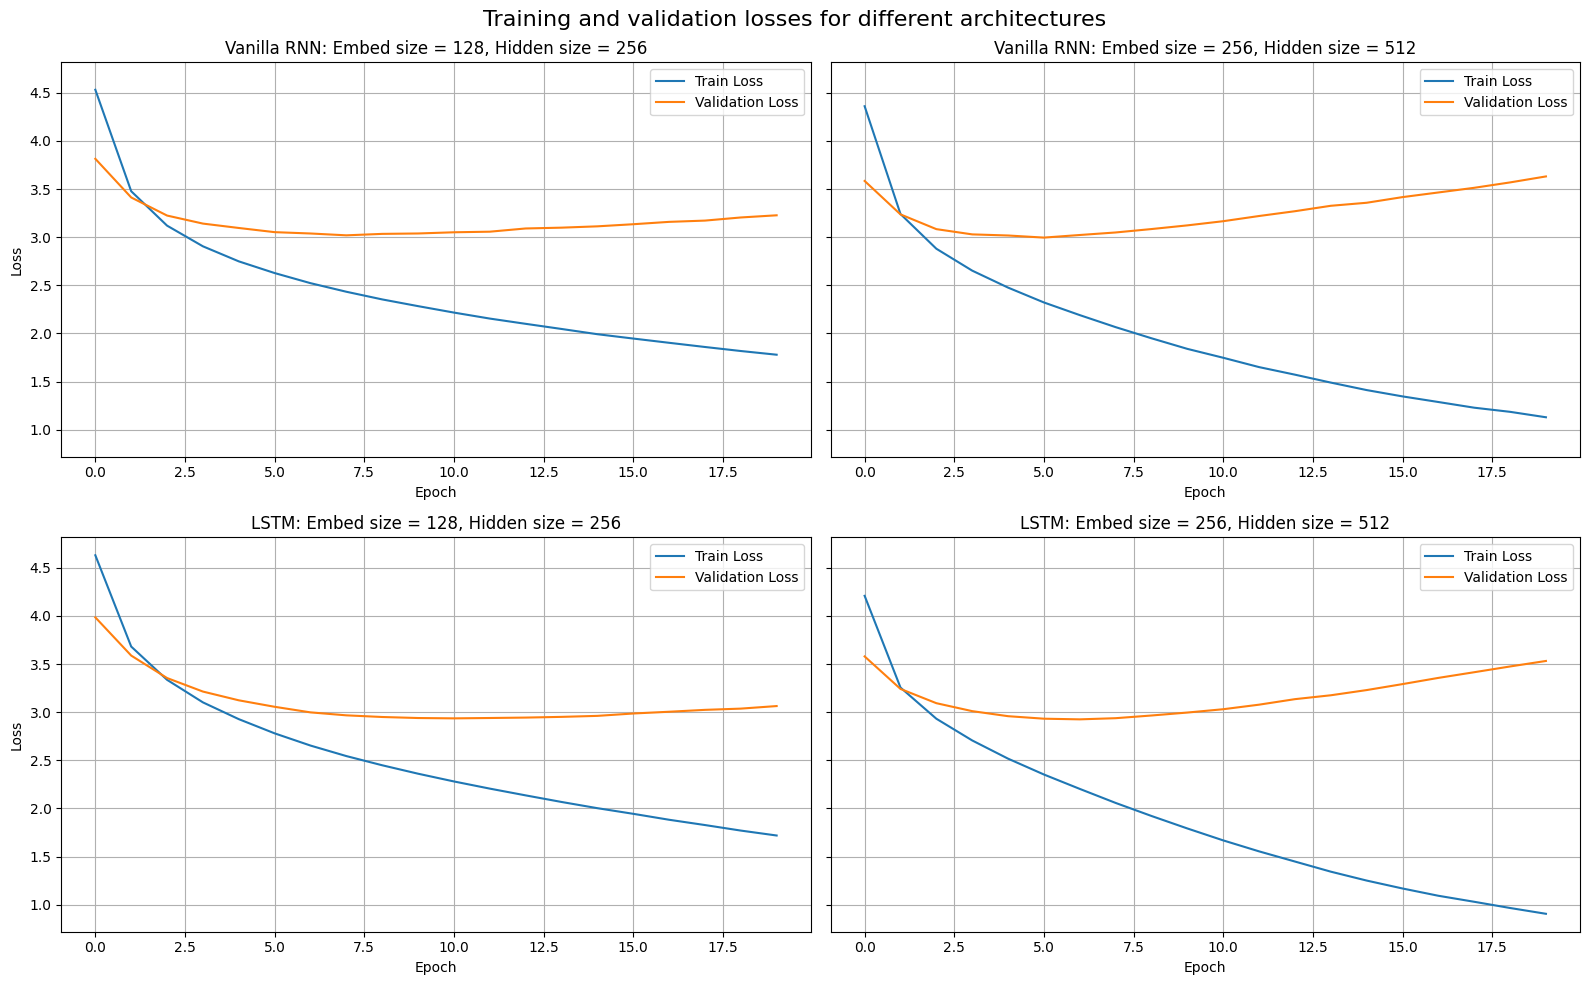

In [47]:
#plot
fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharey=True)

#RNN embed_size = 128, hidden_size = 256
axs[0,0].plot(training_results['RNN_128_256']['train_losses'], label='Train Loss')
axs[0,0].plot(training_results['RNN_128_256']['valid_losses'], label='Validation Loss')
axs[0,0].set_title('Vanilla RNN: Embed size = 128, Hidden size = 256')
axs[0,0].set_xlabel('Epoch')
axs[0,0].set_ylabel('Loss')
axs[0,0].legend()
axs[0,0].grid(True)

#RNN embed_size = 256, hidden_size = 512
axs[0,1].plot(training_results['RNN_256_512']['train_losses'], label='Train Loss')
axs[0,1].plot(training_results['RNN_256_512']['valid_losses'], label='Validation Loss')
axs[0,1].set_title('Vanilla RNN: Embed size = 256, Hidden size = 512')
axs[0,1].set_xlabel('Epoch')
axs[0,1].legend()
axs[0,1].grid(True)

#LSTM embed_size = 128, hidden_size = 256
axs[1,0].plot(training_results['LSTM_128_256']['train_losses'], label='Train Loss')
axs[1,0].plot(training_results['LSTM_128_256']['valid_losses'], label='Validation Loss')
axs[1,0].set_title('LSTM: Embed size = 128, Hidden size = 256')
axs[1,0].set_xlabel('Epoch')
axs[1,0].set_ylabel('Loss')
axs[1,0].legend()
axs[1,0].grid(True)

#LSTM embed_size = 256, hidden_size = 512
axs[1,1].plot(training_results['LSTM_256_512']['train_losses'], label='Train Loss')
axs[1,1].plot(training_results['LSTM_256_512']['valid_losses'], label='Validation Loss')
axs[1,1].set_title('LSTM: Embed size = 256, Hidden size = 512')
axs[1,1].set_xlabel('Epoch')
axs[1,1].legend()
axs[1,1].grid(True)

plt.suptitle('Training and validation losses for different architectures', fontsize=16)
plt.tight_layout()
plt.show()

**Analysis**

In this comparison of the four decoders, I have used the default learning rate and weight decay for the Adam optimizer. I will fine tune these parameters later.

In general, for all models, the training loss decreases monotonically, while the validation loss initially decreases and then increases slightly. This shows that all models suffer from overfitting, albeit to different extents.

The worst model is the RNN with an embedding size of 256 and a hidden size of 512. Here, overfitting occurs early (minimum in validation loss around epoch 6) and the training-validation gap is large. The situation improves only slightly by swapping for the LSTM architecture (with same embedding and hidden sizes): the main difference is that the validation loss minimum (which occurs around epoch 7) is slightly lower.

Overfitting is considerably decreased by reducing both embedding and hidden sizes for both RNN and LSTM. The minimum in the validation loss curves occurs later (around epoch 8 for RNN and around epoch 11 for LSTM). This is beneficial, because it means that the model can learn more from the training data before its generalization ability deteriorates. The validation loss minimum for LSTM is also slightly lower than for RNN.

Overall, LSTM performs slightly better than RNN (probably due to its better handling of long-term dependencies), and smaller embedding and hidden sizes yield better generalization performance (probably because of the too large number of parameters associated with bigger architecture sizes, which causes overfitting on such a small dataset).

I select the LSTM decoder with embed_size = 128 and hidden_size = 256 for further tuning below. Below, I also apply early stopping so that I store the weights of the model before it starts overfitting.

In [48]:
#reset the seeds
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

#re-instantiate the best decoder
decoder = DecoderRNN(2048, len(coco_vocabulary), rnn_type='LSTM', embed_size=128, hidden_size=256).to(device)

#Training best decoder with early stopping
best_decoder_results = {'state_dict': None, 'train_losses': [], 'valid_losses': []} #dictionary to store results

patience = 3
best_valid_loss = float('inf')
counter = 0

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(decoder.parameters(), lr=5e-4, weight_decay=1e-4)

num_epochs = 40

for epoch in range(num_epochs):
    #set the decoder in training mode
    decoder.train()

    train_running_loss = 0.0
    valid_running_loss = 0.0

    for features, captions, lengths in train_loader:
        features, captions = features.to(device), captions.to(device)

        #zero the parameter gradients
        optimizer.zero_grad()

        #forward pass
        outputs = decoder(features, captions[:, :-1], lengths-1)

        #pack the labels to match the outputs
        labels = pack_padded_sequence(captions, lengths, batch_first=True, enforce_sorted=False)
        labels = labels.data

        #calculate the loss of the current batch
        loss = criterion(outputs, labels)

        #backward pass and optimize
        loss.backward()
        optimizer.step()

        #calculate training running loss
        train_running_loss += loss.item() * features.size(0) #Total batch loss = average batch loss * batch size

    #calculate training loss for each epoch
    train_loss = train_running_loss / len(train_loader.dataset)
    best_decoder_results['train_losses'].append(train_loss)

    #set the decoder in evaluation mode
    decoder.eval()
    with torch.no_grad():
      for features, captions, lengths in valid_loader:
            features, captions = features.to(device), captions.to(device)

            outputs = decoder(features, captions[:, :-1], lengths-1)

            labels = pack_padded_sequence(captions, lengths, batch_first=True, enforce_sorted=False)
            labels=labels.data

            loss = criterion(outputs, labels)
            valid_running_loss += loss.item() * features.size(0)

    #calculate validation loss for each epoch
    valid_loss = valid_running_loss / len(valid_loader.dataset)
    best_decoder_results['valid_losses'].append(valid_loss)

    #print losses
    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

    #early stopping
    if valid_loss < best_valid_loss:
      best_valid_loss = valid_loss
      counter = 0

      #store best decoder in dictionary
      best_decoder_results['state_dict'] = decoder.state_dict()
    else:
      counter +=1
      if counter>= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

Epoch [1/40], Training Loss: 5.0277, Validation Loss: 4.3720
Epoch [2/40], Training Loss: 4.0986, Validation Loss: 3.9863
Epoch [3/40], Training Loss: 3.7907, Validation Loss: 3.7604
Epoch [4/40], Training Loss: 3.5794, Validation Loss: 3.5919
Epoch [5/40], Training Loss: 3.4049, Validation Loss: 3.4638
Epoch [6/40], Training Loss: 3.2584, Validation Loss: 3.3435
Epoch [7/40], Training Loss: 3.1364, Validation Loss: 3.2539
Epoch [8/40], Training Loss: 3.0338, Validation Loss: 3.1820
Epoch [9/40], Training Loss: 2.9484, Validation Loss: 3.1370
Epoch [10/40], Training Loss: 2.8762, Validation Loss: 3.0900
Epoch [11/40], Training Loss: 2.8154, Validation Loss: 3.0547
Epoch [12/40], Training Loss: 2.7606, Validation Loss: 3.0296
Epoch [13/40], Training Loss: 2.7140, Validation Loss: 3.0079
Epoch [14/40], Training Loss: 2.6732, Validation Loss: 2.9843
Epoch [15/40], Training Loss: 2.6331, Validation Loss: 2.9713
Epoch [16/40], Training Loss: 2.5982, Validation Loss: 2.9666
Epoch [17/40], Tr

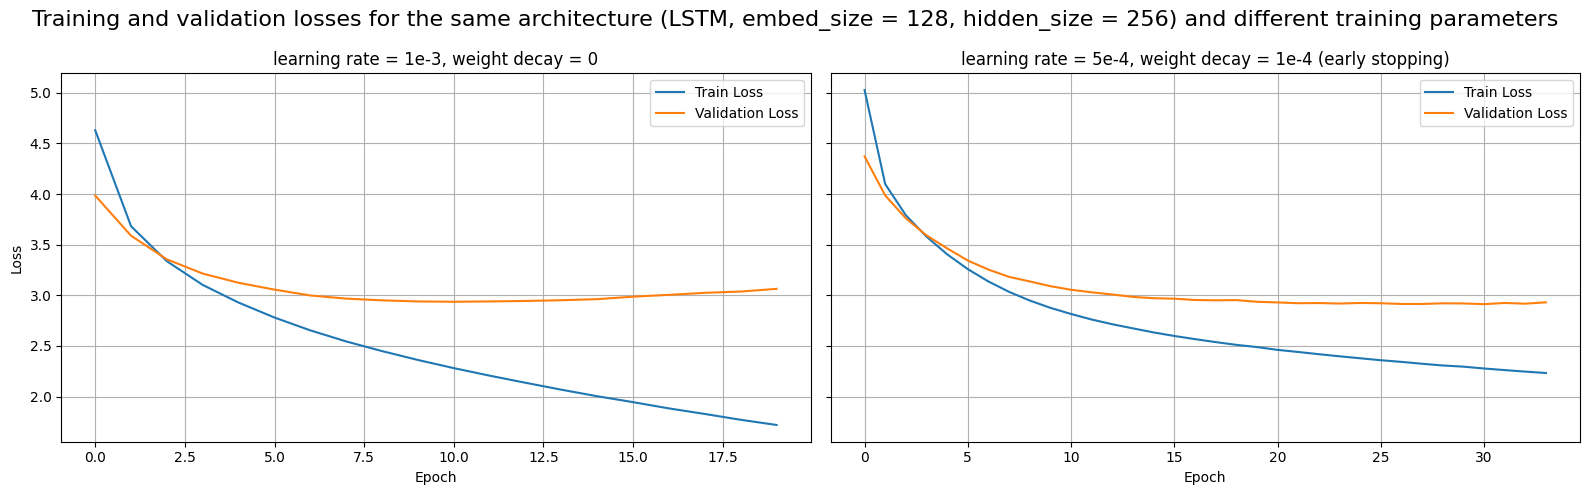

In [49]:
#plot
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

#LSTM embed_size = 128, hidden_size = 256, learning rate = 1e-3, weight decay = 0
axs[0].plot(training_results['LSTM_128_256']['train_losses'], label='Train Loss')
axs[0].plot(training_results['LSTM_128_256']['valid_losses'], label='Validation Loss')
axs[0].set_title('learning rate = 1e-3, weight decay = 0')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

#LSTM embed_size = 128, hidden_size = 256, learning rate = 5e-4, weight decay = 1e-4
axs[1].plot(best_decoder_results['train_losses'], label='Train Loss')
axs[1].plot(best_decoder_results['valid_losses'], label='Validation Loss')
axs[1].set_title('learning rate = 5e-4, weight decay = 1e-4 (early stopping)')
axs[1].set_xlabel('Epoch')
axs[1].legend()
axs[1].grid(True)

plt.suptitle('Training and validation losses for the same architecture (LSTM, embed_size = 128, hidden_size = 256) and different training parameters', fontsize=16)
plt.tight_layout()
plt.show()

**Analysis**

I selected a smaller learning rate and a non-zero weight decay to further improve the generalization ability of the model. Now, the model overfits much later (the minimum in the validation loss curve has clearly shifted significantly to the right (higher number of epochs)). Given more time, I would explore more systematically these two parameters and possibly explore their effects on the individual architectures.

Here, I take this trained decoder as the decoder I will use for the rest of the project.  

### 3.3 Weight tying in the decoder

In [50]:
#In my decoder architecture,
#the layer that maps token indices to embedding vectors is "embedding"
#the layer that maps RNN hidden states to voc scores is "linear3"
print(decoder)

DecoderRNN(
  (linear1): Linear(in_features=2048, out_features=256, bias=True)
  (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear2): Linear(in_features=256, out_features=128, bias=True)
  (embedding): Embedding(2390, 128)
  (rnn): LSTM(128, 256, batch_first=True)
  (linear3): Linear(in_features=256, out_features=2390, bias=True)
)


In [51]:
#weight tying is not possible with these shapes
print(decoder.embedding.weight.shape)
print(decoder.linear3.weight.shape)

torch.Size([2390, 128])
torch.Size([2390, 256])


In [52]:
#update decoder architecture to allow for weight tying; I match embed_size and hidden_size
class DecoderRNN_WeightTied(nn.Module):
    def __init__(self, input_size, vocab_size, rnn_type='LSTM', embed_size=256, hidden_size=256, num_layers=1, max_seq_length=47):
        """
        Initialize the DecoderRNN.
        Inputs:
        - input_size: Size of the input image feature vector
        - vocab_size: Size of the vocabulary (number of unique words in captions)
        - rnn_type: Type of network used (RNN or LSTM)
        - embed_size: Dimensionality of word embeddings
        - hidden_size: Size of the RNN's hidden state
        - num_layers: Number of layers in the RNN
        - max_seq_length: Maximum length of the generated captions
        """
        super(DecoderRNN_WeightTied, self).__init__()
        self.input_size = input_size
        self.vocab_size = vocab_size
        self.rnn_type = rnn_type.upper()
        self.embed_size = embed_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.max_seq_length = max_seq_length

        #linear layer: the output dimension matches the RNN hidden state size
        self.linear1 = nn.Linear(self.input_size, self.hidden_size)

        #batch normalization layer
        self.bn = nn.BatchNorm1d(num_features=self.hidden_size)

        #linear layer: the output dimension matches the embedding size (to allow concatenation of image features and word embeddings later)
        self.linear2 = nn.Linear(self.hidden_size, self.embed_size)

        #embedding layer
        self.embedding = nn.Embedding(num_embeddings=self.vocab_size, embedding_dim=self.embed_size)

        #RNN architecture: I experimented both with Vanilla RNN and LSTM
        if self.rnn_type == 'LSTM':
          self.rnn = nn.LSTM(input_size=self.embed_size, hidden_size=self.hidden_size, num_layers=self.num_layers, batch_first=True)

        elif self.rnn_type == 'RNN':
          self.rnn = nn.RNN(input_size=self.embed_size, hidden_size=self.hidden_size, num_layers=self.num_layers, batch_first=True)

        #linear layer: raw confidence values over the vocabulary
        self.linear3 = nn.Linear(self.hidden_size, self.vocab_size, bias=False) #because the embedding layer has no bias

        #weight tying
        self.linear3.weight = self.embedding.weight


    def forward(self, features, captions, lengths):
        """
        Decode image feature vectors and generate captions.
        Inputs:
        - features: Image features extracted from the EncoderCNN.
        - captions: Padded tokenized captions.
        - lengths: Actual lengths of captions before padding.
        Outputs:
        - outputs: Vocabulary predictions for each time step.
        """

        # STEP 1: Transform the image features using the Linear + BN layer
        features = features.squeeze(1) #shape [64, 2048]
        im_features = self.linear1(features) #shape [64, 256]
        im_features = self.bn(im_features) #shape [64, 256]
        im_features = self.linear2(im_features) #shape [64, 256]

        # STEP 2: Convert captions to embeddings using the embedding layer
        embeddings = self.embedding(captions) #shape [64, 47, 256]

        # STEP 3: Concatenate image features and word embeddings
        im_features = im_features.unsqueeze(1) #shape [64, 1, 256]
        embeddings = torch.cat((im_features, embeddings), dim=1) #shape [64, 48, 256]

        # STEP 4: create a variable called `packed` that the RNN will process in the next step.
        lengths = [length + 1 for length in lengths] #to account for the added image feature
        packed = pack_padded_sequence(embeddings, lengths, batch_first=True, enforce_sorted=False)

        # STEP 5: Processing the packed sequences with the RNN
        output_packed, hiddens = self.rnn(packed)

        # STEP 6: Transform the hidden states to output vocabulary probabilities
        outputs = self.linear3(output_packed.data)

        return outputs

In [53]:
#reset the seeds
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

#instantiate this new decoder
decoder = DecoderRNN_WeightTied(2048, len(coco_vocabulary)).to(device)

#Training this new decoder with early stopping
weight_tied_decoder_results = {'state_dict': None, 'train_losses': [], 'valid_losses': []} # Dictionary to store results

patience = 3
best_valid_loss = float('inf')
counter = 0

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(decoder.parameters(), lr=5e-4, weight_decay=1e-4)

num_epochs = 40

for epoch in range(num_epochs):
    #set the decoder in training mode
    decoder.train()

    train_running_loss = 0.0
    valid_running_loss = 0.0

    for features, captions, lengths in train_loader:
        features, captions = features.to(device), captions.to(device)

        #zero the parameter gradients
        optimizer.zero_grad()

        #forward pass
        outputs = decoder(features, captions[:, :-1], lengths-1) #shortened the captions and lengths to match with label sizes when calculating loss

        #pack the labels to match the outputs
        labels = pack_padded_sequence(captions, lengths, batch_first=True, enforce_sorted=False)
        labels = labels.data

        #calculate the loss of the current batch
        loss = criterion(outputs, labels)

        #backward pass and optimize
        loss.backward()
        optimizer.step()

        #calculate training running loss
        train_running_loss += loss.item() * features.size(0) #Total batch loss = average batch loss * batch size

    #calculate training loss for each epoch
    train_loss = train_running_loss / len(train_loader.dataset)
    weight_tied_decoder_results['train_losses'].append(train_loss)

    #set the decoder in evaluation mode
    decoder.eval()
    with torch.no_grad():
      for features, captions, lengths in valid_loader:
            features, captions = features.to(device), captions.to(device)

            outputs = decoder(features, captions[:, :-1], lengths-1)

            labels = pack_padded_sequence(captions, lengths, batch_first=True, enforce_sorted=False)
            labels=labels.data

            loss = criterion(outputs, labels)
            valid_running_loss += loss.item() * features.size(0)

    #calculate validation loss for each epoch
    valid_loss = valid_running_loss / len(valid_loader.dataset)
    weight_tied_decoder_results['valid_losses'].append(valid_loss)

    #print losses
    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

    #early stopping
    if valid_loss < best_valid_loss:
      best_valid_loss = valid_loss
      counter = 0

      #store weight tied decoder in dictionary
      weight_tied_decoder_results['state_dict'] = decoder.state_dict()
    else:
      counter +=1
      if counter>= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

Epoch [1/40], Training Loss: 4.9741, Validation Loss: 4.2138
Epoch [2/40], Training Loss: 3.8305, Validation Loss: 3.8430
Epoch [3/40], Training Loss: 3.4688, Validation Loss: 3.6384
Epoch [4/40], Training Loss: 3.2347, Validation Loss: 3.5229
Epoch [5/40], Training Loss: 3.0611, Validation Loss: 3.4328
Epoch [6/40], Training Loss: 2.9219, Validation Loss: 3.3776
Epoch [7/40], Training Loss: 2.8046, Validation Loss: 3.3450
Epoch [8/40], Training Loss: 2.7044, Validation Loss: 3.3172
Epoch [9/40], Training Loss: 2.6178, Validation Loss: 3.2909
Epoch [10/40], Training Loss: 2.5373, Validation Loss: 3.2565
Epoch [11/40], Training Loss: 2.4685, Validation Loss: 3.2571
Epoch [12/40], Training Loss: 2.4035, Validation Loss: 3.2572
Epoch [13/40], Training Loss: 2.3449, Validation Loss: 3.2412
Epoch [14/40], Training Loss: 2.2899, Validation Loss: 3.2124
Epoch [15/40], Training Loss: 2.2380, Validation Loss: 3.2425
Epoch [16/40], Training Loss: 2.1906, Validation Loss: 3.2376
Epoch [17/40], Tr

In [54]:
#Quick sanity check
decoder.embedding.weight is decoder.linear3.weight

True

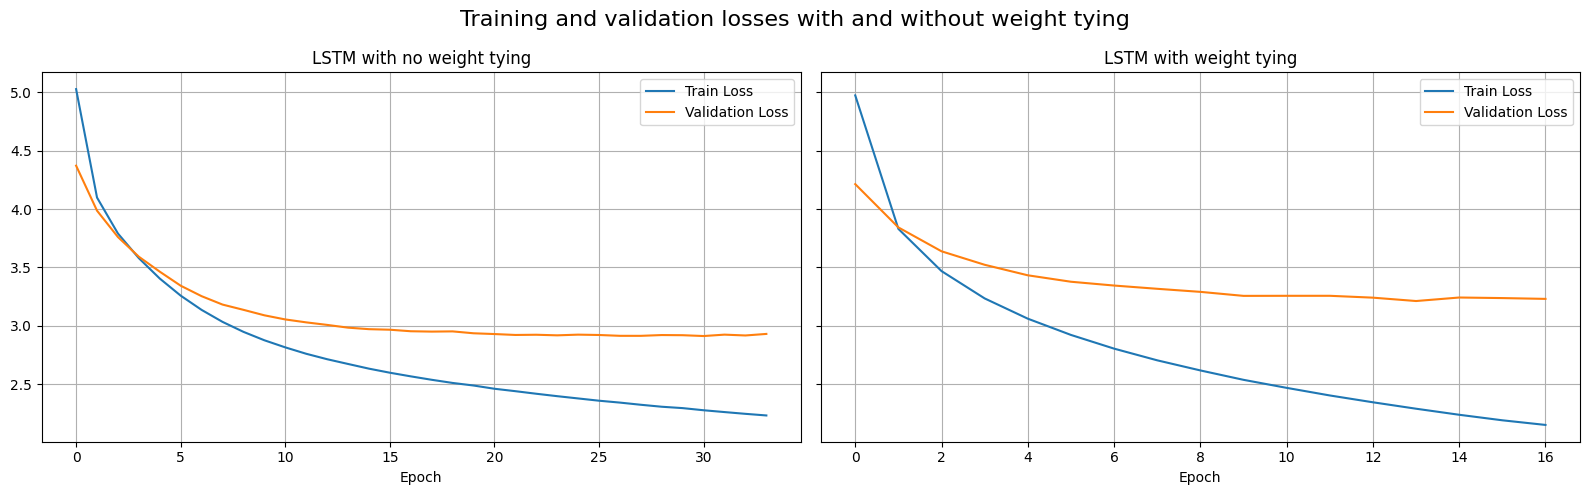

In [55]:
#plot
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

#LSTM with no weight tying
axs[0].plot(best_decoder_results['train_losses'], label='Train Loss')
axs[0].plot(best_decoder_results['valid_losses'], label='Validation Loss')
axs[0].set_title('LSTM with no weight tying')
axs[0].set_xlabel('Epoch')
axs[0].legend()
axs[0].grid(True)

#LSTM with weight tying
axs[1].plot(weight_tied_decoder_results['train_losses'], label='Train Loss')
axs[1].plot(weight_tied_decoder_results['valid_losses'], label='Validation Loss')
axs[1].set_title('LSTM with weight tying')
axs[1].set_xlabel('Epoch')
axs[1].legend()
axs[1].grid(True)

plt.suptitle('Training and validation losses with and without weight tying', fontsize=16)
plt.tight_layout()
plt.show()

**Analysis**

After implementing weight tying in my best decoder model, it is clear that the validation loss is increased and it reaches the minimum much earlier (smaller number of epochs). The train-validation gap has also increased. These results indicate that weight tying makes overfitting more pronounced and overall decreases the generalization capacity of the decoder.

This is somewhat unexpected, as the number of parameters that the model needs to learn is reduced with weight tying, and this in itself should reduce overfitting (it should act as a form of regularization). However, it could be that the restrictions imposed on the model architecture to enable weight tying (embed_size=hidden_size) limit the model flexibility and degrade its generalization performance.

## 4 Generate predictions on test data

### 4.1 Greedy caption generation

Using greedy decoding (selecting the most likely word at each time step), I display 5 sample test images containing different objects, along with the model’s generated captions and all the reference captions for each.

In [56]:
#re-instantiate the best decoder and load the optimized weights
decoder = DecoderRNN(2048, len(coco_vocabulary), rnn_type='LSTM', embed_size=128, hidden_size=256).to(device)
decoder.load_state_dict(best_decoder_results['state_dict'])

<All keys matched successfully>

In [57]:
def greedy_caption_generation(decoder, img_feature, vocabulary, max_length=47):
  """Generate a caption for a given image using greedy decoding
   Args:
        decoder: trained decoder.
        img_feature: tensor of shape [2048].
        vocabulary: vocabulary object.
        max_length: max caption length.
    Returns:
        string: generated caption.
    """

  #set decoder in evaluation mode
  decoder.eval()

  #initialize list for generated caption
  greedy_caption = []

  with torch.no_grad():
      feature = img_feature.unsqueeze(0) #shape [1, 2048]
      feature = decoder.linear1(feature) #shape [1, 256]
      feature = decoder.bn(feature) #shape [1, 256]
      feature = decoder.linear2(feature) #shape [1, 128]

      #use image feature as first input
      inputs = feature.unsqueeze(1) #shape [1, 1, 128]

      #initialize the LSTM hidden (h) and cell (c) stats to 0
      states = None

      #greedy loop
      for i in range(max_length):
        #forward pass: takes current inputs and previous states; returns outputs and updated states
        outputs, states = decoder.rnn(inputs, states) #shape [1, 1, 256]

        #scores over the vocabulary
        scores = decoder.linear3(outputs.squeeze(1)) #shape [1, 2390], where 2390 is the vocab_size
        predicted_id = scores.argmax(dim=1) #shape [1]

        #get the word
        word = vocabulary.idx2word[predicted_id.item()]
        if word == '<end>':
          break

        greedy_caption.append(word)

        #use the predicted id as the next input
        inputs = decoder.embedding(predicted_id).unsqueeze(1)

  return ' '.join(greedy_caption)

In [58]:
#get test image ids
test_image_ids = test_set['image_id'].unique()

#select 5 random ones
random.seed(seed)
sample_image_ids = random.sample(list(test_image_ids), 5)

In [59]:
#function to get all reference captions for a given image id in the test set
def get_reference_captions(df, image_id):
  """Returns a list of all captions that correspond to a given image id"""
  captions = df[df['image_id'] == image_id]['clean_caption'].to_list()
  return captions

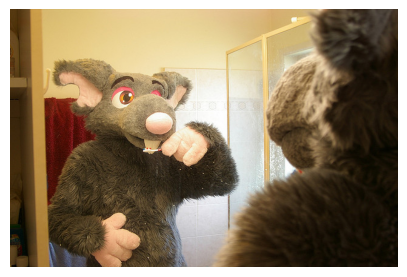

Greedy caption: 
 a woman is standing in a bathroom mirror 

Reference captions:
- a large gray rat standing in front of a bathroom mirror
- a giant rat brushing its teeth in the mirror
- a person in a mouse costume brushing their mouse teeth 
- a person that is dressed up in a costume
- a person in a rat suit brushing their teeth


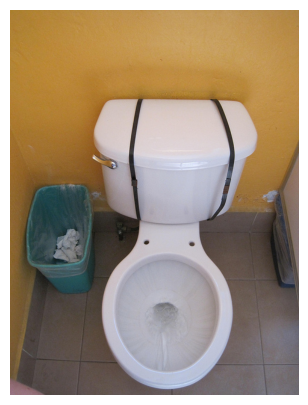

Greedy caption: 
 a white toilet in a bathroom with a <unk> 

Reference captions:
- the complete view of a bathroom with many things to see

- a toilet basin and a bucket next to it
- a small bathroom has a toilet with stripes on it
- a broken toilet flushing beside a trash can
- a restroom toilet missing a lid next to a trash can


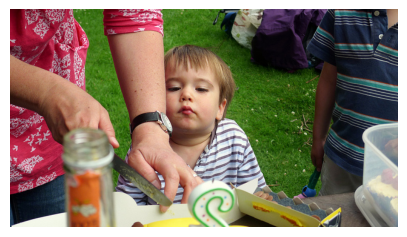

Greedy caption: 
 a little boy is standing on a beach 

Reference captions:
- small child waiting for his piece of birthday cake
- a little boy watching someone cut a birthday cake
- a little boy waits to have some birthday cake
- a woman cutting up a birthday cake at an outdoor party
- a young boy looks at a woman cutting a cake


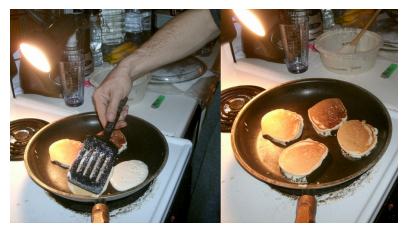

Greedy caption: 
 a woman is sitting on a plate with a knife 

Reference captions:
- some one is cooking and flipping pancakes on a stove
- pancakes are cooking in a skillet on the stove
- a side by side picture of pancakes being cooked
- before and after photos of a man making pancakes
- a person frying some pancakes in a pan on a stove top


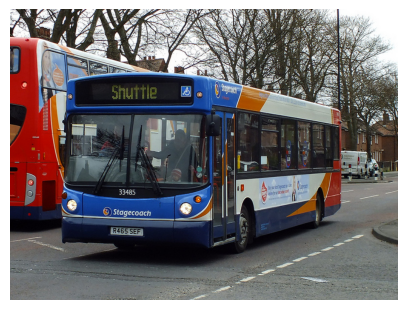

Greedy caption: 
 a bus is parked in a city street 

Reference captions:
- a bus is driving on the street next to a double decker bus
- a transit bus riding down a street past another bus
- the city bus is riding down the street near another bus
- a shuttle traveling down a street in a rural area
- a photo of a shuttle bus driving down the road


In [60]:
for image_id in sample_image_ids:
  #get the path of the image
  img_folder = '/content/coco_subset_images/coco_subset_images/images'
  img_path = os.path.join(img_folder, test_set[test_set['image_id']==image_id]['file_name'].iloc[0])

  #load the image with PIL and convert to 3 channels (RGB)
  img = Image.open(img_path).convert('RGB')

  #get corresponding image feature
  img_feature = img_features[image_id].to(device)

  #generate caption using greedy decoding
  greedy_caption = greedy_caption_generation(decoder, img_feature, coco_vocabulary)

  #get all reference captions
  reference_captions = get_reference_captions(test_set, image_id)

  #plot
  plt.figure(figsize=(5,5))
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  print('Greedy caption: \n', greedy_caption, '\n')
  print('Reference captions:')
  for ref in reference_captions:
      print('-', ref)

### 4.2 Beam search caption generation

Here, I generate captions using beam search decoding instead of greedy decoding.

In [61]:
def beam_search_caption_generation(decoder, img_feature, vocabulary, beam_size=5, max_length=47):
  """Generate a caption for a given image using beam search decoding
   Args:
        decoder: trained decoder.
        img_feature: tensor of shape [2048].
        vocabulary: vocabulary object.
        beam_size: number of beams.
        max_length: max caption length.
    Returns:
        string: generated caption.
    """

  #set decoder in evaluation mode
  decoder.eval()

  with torch.no_grad():
      feature = img_feature.unsqueeze(0) #shape [1, 2048]
      feature = decoder.linear1(feature) #shape [1, 256]
      feature = decoder.bn(feature) #shape [1, 256]
      feature = decoder.linear2(feature) #shape [1, 128]

      #use image feature as first input
      inputs = feature.unsqueeze(1) #shape [1, 1, 128]

      #initialization
      sequence = [] #sequence of words
      log_prob = 0.0 #cumulative log-probabilities
      states = None #LSTM states

      beams = [(sequence, log_prob, states, inputs)]

      #beam search loop
      for i in range(max_length):
        new_beams = []

        for sequence, score, states, current_inputs in beams:

          #if beam has already ended, append it
          if current_inputs is None:
            new_beams.append((sequence, score, states, None))
            continue

          #ensure inputs are on the correct device
          current_inputs = current_inputs.to(device)

          #forward pass
          outputs, new_states = decoder.rnn(current_inputs, states) #shape [1, 1, 256]

          #scores over the vocabulary
          scores = decoder.linear3(outputs.squeeze(1)) #shape [1, 2390], where 2390 is the vocab_size

          #log-probabilities over the vocabulary
          log_probs = log_softmax(scores, dim=1)

          #select top K log-probabilities and corresponding word ids for this beam
          top_log_probs, top_ids = torch.topk(log_probs, beam_size)

          for k in range(beam_size):
            predicted_id = top_ids[0, k]
            word = vocabulary.idx2word[predicted_id.item()]
            new_score = score + top_log_probs[0, k].item()
            new_sequence = sequence + [word]

            if word == '<end>':
              new_beams.append((new_sequence, new_score, new_states, None))
            else:
              #unsqueeze twice to maintain shape [1, 1, embed_size]
              new_inputs = decoder.embedding(predicted_id).view(1, 1, -1)
              new_beams.append((new_sequence, new_score, new_states, new_inputs))

        #keep top K beams
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]

        #if all top beams have finished (None input), then stop
        if all(beam[3] is None for beam in beams):
          break

      #select best beam and remove <end> if present
      beam_search_caption = beams[0][0]

      if beam_search_caption and beam_search_caption[-1] == '<end>':
        beam_search_caption = beam_search_caption[:-1]

      return ' '.join(beam_search_caption)

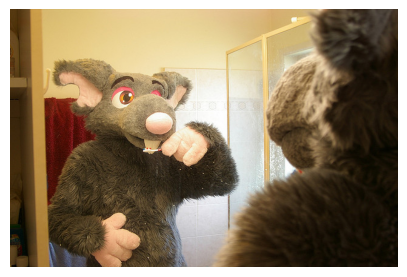

Beam search caption: 
 a woman is brushing her teeth in a bathroom 

Reference captions:
- a large gray rat standing in front of a bathroom mirror
- a giant rat brushing its teeth in the mirror
- a person in a mouse costume brushing their mouse teeth 
- a person that is dressed up in a costume
- a person in a rat suit brushing their teeth


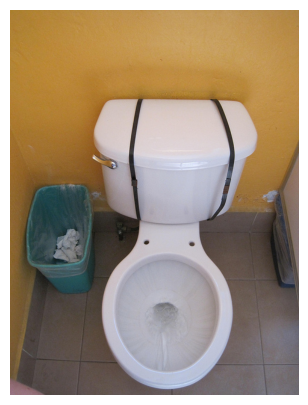

Beam search caption: 
 a close up of a toilet in a bathroom 

Reference captions:
- the complete view of a bathroom with many things to see

- a toilet basin and a bucket next to it
- a small bathroom has a toilet with stripes on it
- a broken toilet flushing beside a trash can
- a restroom toilet missing a lid next to a trash can


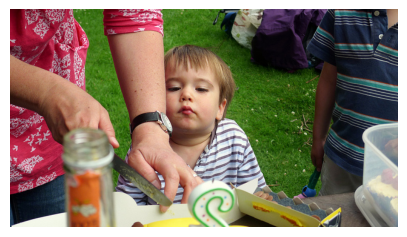

Beam search caption: 
 a young boy is sitting on a beach 

Reference captions:
- small child waiting for his piece of birthday cake
- a little boy watching someone cut a birthday cake
- a little boy waits to have some birthday cake
- a woman cutting up a birthday cake at an outdoor party
- a young boy looks at a woman cutting a cake


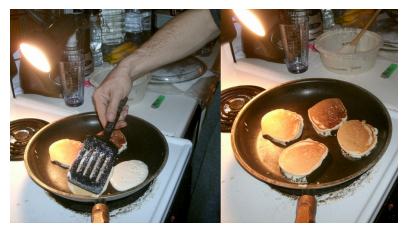

Beam search caption: 
 a couple of food that are on a table 

Reference captions:
- some one is cooking and flipping pancakes on a stove
- pancakes are cooking in a skillet on the stove
- a side by side picture of pancakes being cooked
- before and after photos of a man making pancakes
- a person frying some pancakes in a pan on a stove top


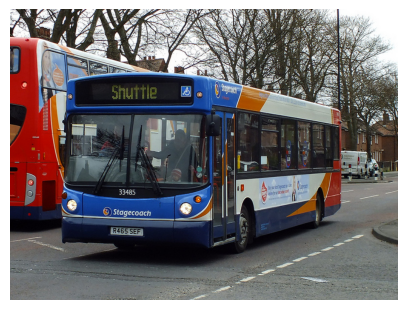

Beam search caption: 
 a bus is parked in a parking lot 

Reference captions:
- a bus is driving on the street next to a double decker bus
- a transit bus riding down a street past another bus
- the city bus is riding down the street near another bus
- a shuttle traveling down a street in a rural area
- a photo of a shuttle bus driving down the road


In [62]:
for image_id in sample_image_ids:
  #get the path of the image
  img_folder = '/content/coco_subset_images/coco_subset_images/images'
  img_path = os.path.join(img_folder, test_set[test_set['image_id']==image_id]['file_name'].iloc[0])

  #load the image with PIL and convert to 3 channels (RGB)
  img = Image.open(img_path).convert('RGB')

  #get corresponding image feature
  img_feature = img_features[image_id].to(device)

  #generate caption using beam search decoding
  beam_search_caption = beam_search_caption_generation(decoder, img_feature, coco_vocabulary)

  #get all reference captions
  reference_captions = get_reference_captions(test_set, image_id)

  #plot
  plt.figure(figsize=(5,5))
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  print('Beam search caption: \n', beam_search_caption, '\n')
  print('Reference captions:')
  for ref in reference_captions:
      print('-', ref)

**Analysis**

Both methods correctly identify simpler images (such as the toilet (image 2) and the bus (image 5)), with beam search providing more accurate and fluent captions (avoiding 'unk'). However, neither method is able to identify the fact that the bus is in motion.

For more complex images (such as the rat (image 1), the boy (image 3), and the food (image 4), beam search is again more accurate (for instance, it detects the action of tooth brushing in image 1 and provides a better caption for image 4). However, both methods struggle with these more complex images, as they seem to struggle to identify details correctly.

Note: for the beam search method, I used beam_size=5. I found it yielded slightly better results than 3 and 4.

## 5 Caption length statistics and analysis

In [63]:
#simple function to retrieve caption length
def caption_length (caption):
  return len(caption.split())

In [64]:
results = []

#loop over image ids in the test set
for image_id in test_image_ids:

  #reference captions
  captions = get_reference_captions(test_set, image_id)
  for caption in captions:
    results.append({'image_id': image_id, 'caption_type': 'reference', 'caption': caption, 'length': caption_length(caption)})

  #greedy captions
  img_feature = img_features[image_id].to(device)
  greedy_caption = greedy_caption_generation(decoder, img_feature, coco_vocabulary)
  results.append({'image_id': image_id, 'caption_type': 'greedy', 'caption': greedy_caption, 'length': caption_length(greedy_caption)})

  #beam search captions
  beam_search_caption = beam_search_caption_generation(decoder, img_feature, coco_vocabulary)
  results.append({'image_id': image_id, 'caption_type': 'beam_search', 'caption': beam_search_caption, 'length': caption_length(beam_search_caption)})

#create a new dataframe
results = pd.DataFrame(results)
results.head()

,image_id,caption_type,caption,length
0,57429,reference,an airplane with its landing wheels out landing,8
1,57429,reference,a plane that is taking off at an airport,9
2,57429,reference,a man takes a picture of an airplane taking off,10
3,57429,reference,a large jet takes off from an airport runway,9
4,57429,reference,the airplane is taking off on the runway at the airport,11


In [65]:
#descriptive statistics
stats = (
    results
    .groupby('caption_type')['length']
    .agg(['min', 'median', 'mean', 'max', 'std'])
    .reset_index()
)

#round to 1 decimal point
stats = stats.round(1)
print(stats.to_string(index=False))

caption_type  min  median  mean  max  std
 beam_search    7     9.0   8.8   12  1.0
      greedy    7     9.0   9.6   17  1.6
   reference    7    10.0  10.5   38  2.4


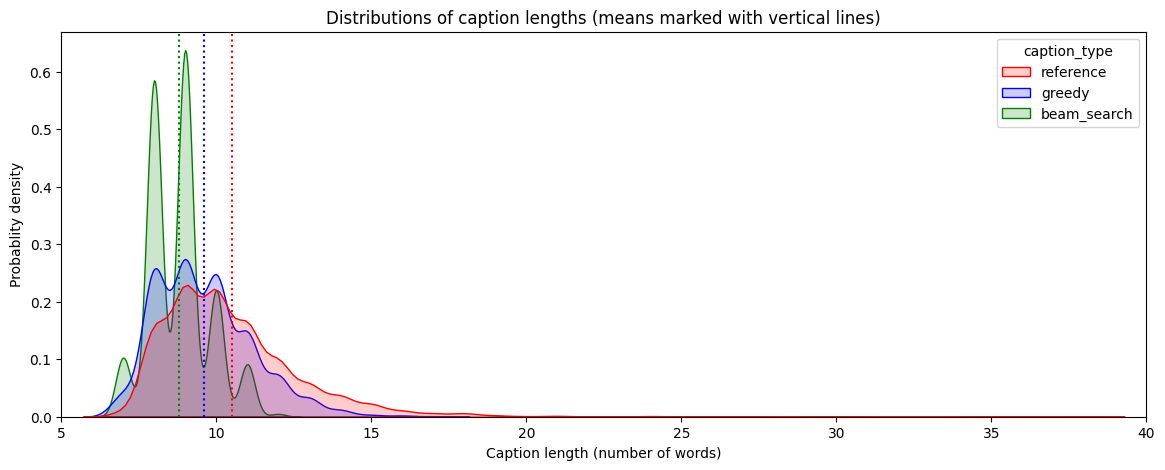

In [66]:
#KDE plots showing distributions of caption lengths with means marked as vertical lines
plt.figure(figsize=(14, 5))
palette = {'beam_search': 'green', 'greedy': 'blue', 'reference': 'red'}

#distributions
sns.kdeplot(data=results, x='length', hue='caption_type', fill=True, palette=palette, alpha=0.2, common_norm=False) #each curve is normalized independently
plt.xlabel('Caption length (number of words)')
plt.ylabel('Probablity density')
plt.title('Distributions of caption lengths (means marked with vertical lines)')

#means
mean_beam_search = stats.loc[stats['caption_type'] == 'beam_search', 'mean'].item()
mean_greedy = stats.loc[stats['caption_type'] == 'greedy', 'mean'].item()
mean_ref = stats.loc[stats['caption_type'] == 'reference', 'mean'].item()

plt.axvline(x=mean_beam_search, color=palette['beam_search'], linestyle=':')
plt.axvline(x=mean_greedy, color=palette['greedy'], linestyle=':')
plt.axvline(x=mean_ref, color=palette['reference'], linestyle=':')

plt.legend
plt.xlim(5,40)
plt.show()

**Analysis**

| Caption Type |   Min   | Median |  Mean  |   Max   |   Std   |
| ------------ |   ---   | ------ |  ----  |   ---   |   ---   |
| Greedy       |   7.0   |  9.0   |  9.6   |   17.0  |   1.6   |
| Beam Search  |   7.0   |  9.0   |  8.8   |   12.0  |   1.0   |
| Ground Truth |   7.0   |  10.0  |  10.5  |   38.0  |   2.4   |

1. **Differences in the descriptive statistics between greedy decoding, beam search, and ground truth.**

On average, the ground-truth captions are longer (mean = 10.5) than both the greedy and beam search captions (means = 9.6 and 8.8, respectively). The max lengths are also significantly different, although 38 for ground truth is a clear outlier (see the KDE plots above), while the min lengths are identical. The standard deviations are also considerably different, with beam search providing the narrowest distribution of lengths (its std is around 0.42 that of the ground truth). Finally, the median is identical for greedy and beam search, and slightly higher for ground truth, consistent with the fact that the ground-truth captions are longer.   

2. **Differences in the shapes of the length distributions.**

The shapes of the length distributions are substantially different. The greater variability in the ground-truth caption lengths (higher std) renders their distribution smoother, with only small peaks noticeable (for instance, those located at 9 and 10). On the other hand, the greedy distribution exhibits more distinct peaks (located at 8, 9 and 10), and the beam search distribution shows even stronger peaks (specifically those located at 8 and 9). The clear peaks observed in the beam search distribution indicate more uniformity in caption length, which is consistent with the lower std of this distribution. All these observations point to the fact that the ground-truth captions contain more details (information) regarding the corresponding images than those that both models can identify, resulting in their shorter captions and more uniform length distributions.

3. **How the choice of decoding strategy influences caption length and sentence termination.**

Greedy decoding produces, on average, slightly longer captions than beam search. This may be due to the fact that, in greedy decoding, the most probable next word is taken, which may end up in the model falling into a repetitive loop, thus generating longer captions (I have actually noticed this in some images I tested). In any case, this effect is not pronounced, as the average length difference between the two methods is only modest.

## 6 Caption evaluation using BLEU score

###  6.1 BLEU score

In [67]:
#initialize new columns in my results df for both BLEU-2 and BLEU-3 (the most sensible choices for short captions)
results['bleu2'] = None
results['bleu3'] = None

#smoothing method to avoid zero BLEU scores caused by missing higher-order n-gram matches
smoothing = SmoothingFunction().method1

for image_id in test_image_ids:
  #get all reference captions
  references = results[(results['image_id'] == image_id) & (results['caption_type'] == 'reference')]['caption'].tolist()
  #tokenize
  ref_tokens = [ref.split() for ref in references]

  #greedy
  idx_greedy = results[(results['image_id'] == image_id) & (results['caption_type'] == 'greedy')].index[0]
  #tokenize
  greedy_tokens = results.loc[idx_greedy, 'caption'].split()
  #calculate the BLEU scores against all ref captions and add them to the df
  results.loc[idx_greedy, 'bleu2'] = sentence_bleu(ref_tokens, greedy_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
  results.loc[idx_greedy, 'bleu3'] = sentence_bleu(ref_tokens, greedy_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing)

  #beam search
  idx_beam_search = results[(results['image_id'] == image_id) & (results['caption_type'] == 'beam_search')].index[0]
  #tokenize
  beam_search_tokens = results.loc[idx_beam_search, 'caption'].split()
  #calculate the BLEU scores against all ref captions and add them to the df
  results.loc[idx_beam_search, 'bleu2'] = sentence_bleu(ref_tokens, beam_search_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
  results.loc[idx_beam_search, 'bleu3'] = sentence_bleu(ref_tokens, beam_search_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing)

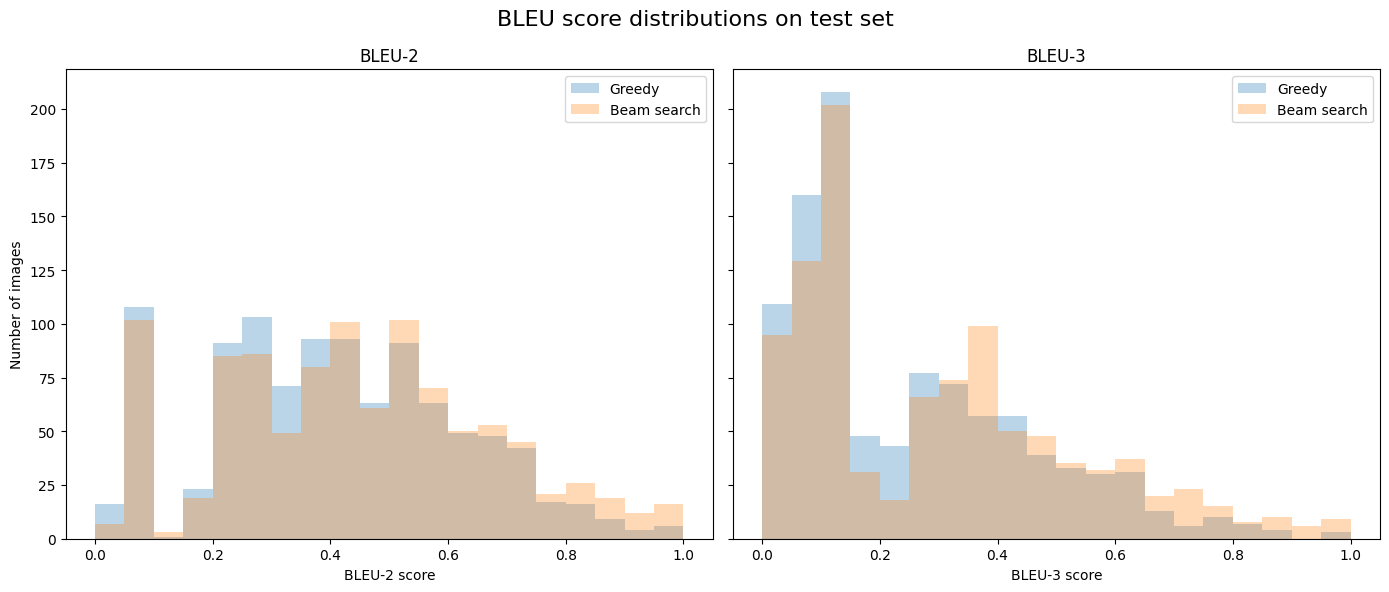

In [68]:
#extract BLEU scores for greedy from the results df
bleu2_greedy = results[results['caption_type'] == 'greedy']['bleu2'].astype(float)
bleu3_greedy = results[results['caption_type'] == 'greedy']['bleu3'].astype(float)

#extract BLEU scores for beam search from the results df
bleu2_beam_search = results[results['caption_type'] == 'beam_search']['bleu2'].astype(float)
bleu3_beam_search = results[results['caption_type'] == 'beam_search']['bleu3'].astype(float)

#plot histograms
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

bins = np.linspace(0, 1, 21)

#BLEU-2
axs[0].hist(bleu2_greedy, bins=bins, alpha=0.3, label='Greedy')
axs[0].hist(bleu2_beam_search, bins=bins, alpha=0.3, label='Beam search')
axs[0].set_xlabel('BLEU-2 score')
axs[0].set_ylabel('Number of images')
axs[0].set_title('BLEU-2')
axs[0].legend()

#BLEU-3
axs[1].hist(bleu3_greedy, bins=bins, alpha=0.3, label='Greedy')
axs[1].hist(bleu3_beam_search, bins=bins, alpha=0.3, label='Beam search')
axs[1].set_xlabel('BLEU-3 score')
axs[1].set_title('BLEU-3')
axs[1].legend()

plt.suptitle('BLEU score distributions on test set', fontsize=16)
plt.tight_layout()
plt.show()

In [69]:
#calculate the BLEU score averages
bleu2_greedy_ave = np.mean(bleu2_greedy)
bleu3_greedy_ave = np.mean(bleu3_greedy)

bleu2_beam_search_ave = np.mean(bleu2_beam_search)
bleu3_beam_search_ave = np.mean(bleu3_beam_search)

print('Average BLEU scores:\n')
print(f'BLEU-2 score for greedy: {bleu2_greedy_ave:.2f}')
print(f'BLEU-2 score for beam search: {bleu2_beam_search_ave:.2f}')
print(f'BLEU-3 score for greedy: {bleu3_greedy_ave:.2f}')
print(f'BLEU-3 score for beam search: {bleu3_beam_search_ave:.2f}')

Average BLEU scores:

BLEU-2 score for greedy: 0.41
BLEU-2 score for beam search: 0.44
BLEU-3 score for greedy: 0.25
BLEU-3 score for beam search: 0.30


**Discussion**

As expected, one can see both from the histograms and from the average score values that BLEU-3 is significantly lower than BLEU-2. This shows that both decoding methods struggle more with longer structural consistency. For this reason, I select BLEU-2 for the subsequent sections, as it seems to provide a more robust metric (also for later comparison with cosine similarity).

On a separate note, it is interesting  to note the fact that the BLEU-3 score for beam search is 20% higher than that for greedy. The discrepancy is not so large for BLEU-2. This indicates that beam search is indeed better at identifying correctly longer word sequences.

### 6.2 BLEU-2 score examples (high and low scores)

In [70]:
#pick a suitable threshold where both greedy and beam search captions are very close to reference captions
threshold = 0.99

#get image ids corresponding to greedy BLEU-2 score close to 1
high_greedy_ids = set(results[(results['caption_type'] == 'greedy') & (results['bleu2'] >= threshold)]['image_id'])

#get image ids corresponding to beam search BLEU-2 score close to 1
high_beam_search_ids = set(results[(results['caption_type'] == 'beam_search') & (results['bleu2'] >= threshold)]['image_id'])

#find the intersection of the two sets
high_ids = list(high_greedy_ids.intersection(high_beam_search_ids))

#get one of these image ids
id_high_bleu = high_ids[0]

#get corresponding greedy caption
greedy_caption = results[(results['image_id'] == id_high_bleu) & (results['caption_type'] == 'greedy')]['caption'].item()

#get corresponding greedy BLEU-2 score
greedy_bleu = results[(results['image_id'] == id_high_bleu) & (results['caption_type'] == 'greedy')]['bleu2'].item()

#get corresponding beam search caption
beam_search_caption = results[(results['image_id'] == id_high_bleu) & (results['caption_type'] == 'beam_search')]['caption'].item()

#get corresponding beam search BEAM-2 score
beam_search_bleu = results[(results['image_id'] == id_high_bleu) & (results['caption_type'] == 'beam_search')]['bleu2'].item()

#get corresponding reference captions
reference_captions = results[(results['image_id'] == id_high_bleu) & (results['caption_type'] == 'reference')]['caption'].tolist()

print('Greedy predicted caption:', greedy_caption)
print(f'Greedy BLEU-2 score: {greedy_bleu:.2f}\n')
print('Beam search predicted caption:', beam_search_caption)
print(f'Beam search BLEU-2 score: {beam_search_bleu:.2f}\n')
print('Reference captions:')
for ref in reference_captions:
  print('-', ref)

Greedy predicted caption: a young girl holding a toothbrush in her mouth
Greedy BLEU-2 score: 1.00

Beam search predicted caption: a young girl holding a toothbrush in her mouth
Beam search BLEU-2 score: 1.00

Reference captions:
- a little girl chews on the end of a party noise maker
- a little kid that is brushing her teeth
- a young girl holding a toothbrush in her mouth
- a young girl holding a party horn in her mouth
- a child getting ready to blow a party horn


In [71]:
#pick a suitable threshold where both greedy and beam search captions are very different from reference captions
threshold = 0.05

#get image ids corresponding to greedy BLEU-2 score close to 0
low_greedy_ids = set(results[(results['caption_type'] == 'greedy') & (results['bleu2'] <= threshold)]['image_id'])

#get image ids corresponding to beam search BLEU-2 score close to 0
low_beam_search_ids = set(results[(results['caption_type'] == 'beam_search') & (results['bleu2'] <= threshold)]['image_id'])

#find the intersection of the two sets
low_ids = list(low_greedy_ids.intersection(low_beam_search_ids))

#get one of these image ids
id_low_bleu = low_ids[0]

#get corresponding greedy caption
greedy_caption = results[(results['image_id'] == id_low_bleu) & (results['caption_type'] == 'greedy')]['caption'].item()

#get corresponding greedy BLEU-2 score
greedy_bleu = results[(results['image_id'] == id_low_bleu) & (results['caption_type'] == 'greedy')]['bleu2'].item()

#get corresponding beam search caption
beam_search_caption = results[(results['image_id'] == id_low_bleu) & (results['caption_type'] == 'beam_search')]['caption'].item()

#get corresponding beam search BLEU-2 score
beam_search_bleu = results[(results['image_id'] == id_low_bleu) & (results['caption_type'] == 'beam_search')]['bleu2'].item()

#get corresponding reference captions
reference_captions = results[(results['image_id'] == id_low_bleu) & (results['caption_type'] == 'reference')]['caption'].tolist()

print('Greedy predicted caption:', greedy_caption)
print(f'Greedy BLEU-2 score: {greedy_bleu:.2f}\n')
print('Beam search predicted caption:', beam_search_caption)
print(f'Beam search BLEU-2 score: {beam_search_bleu:.2f}\n')
print('Reference captions:')
for ref in reference_captions:
  print('-', ref)

Greedy predicted caption: a man holding a suitcase and a pair of scissors
Greedy BLEU-2 score: 0.05

Beam search predicted caption: a person holding an umbrella in a room
Beam search BLEU-2 score: 0.04

Reference captions:
- a big wedding cake with three white stories 
- a very large cake with flowers around it
- on the table is a three tiered wedding cake wine goblets and some roses
- a wedding cake that is  layers high and has flowers on it
- a large fourtiered whited frosted cake with purple trim displayed


## 7 Caption evaluation using cosine similarity

###  7.1 Cosine similarity

In [72]:
def caption_to_embedding (caption, vocabulary, decoder, device = device):
  """
  Convert caption to an average embedding vector.
  """
  words = caption.split()

  #get the indices of the words
  idx = [vocabulary.word2idx[word] for word in words if word in vocabulary.word2idx]
  idx = torch.tensor(idx, dtype=torch.long).to(device)

  #get word embeddings
  embeddings = decoder.embedding(idx) #shape [num_words, embed_size]

  #calculate average embedding
  ave_embedding = embeddings.mean(dim=0) #shape [embed_size]

  return ave_embedding

In [73]:
def cos_similarity(embedding1, embedding2):
  """
  Calculate the cosine similarity between two embedding vectors.
  """
  return cosine_similarity(embedding1.unsqueeze(0), embedding2.unsqueeze(0)).item()

In [74]:
#initialize new column in my results df
results['cos_similarity'] = None

for image_id in test_image_ids:
  #get all reference captions
  references = results[(results['image_id'] == image_id) & (results['caption_type'] == 'reference')]['caption'].tolist()
  #caclulate reference embeddings
  ref_embeddings = []
  for ref in references:
    ref_embedding = caption_to_embedding(ref, coco_vocabulary, decoder)
    ref_embeddings.append(ref_embedding)

  #greedy
  idx_greedy = results[(results['image_id'] == image_id) & (results['caption_type'] == 'greedy')].index[0]
  #get greedy caption
  greedy_caption = results.loc[idx_greedy, 'caption']
  #get greedy embedding
  greedy_embedding = caption_to_embedding(greedy_caption, coco_vocabulary, decoder)
  #calculate cosine similarity against all ref captions
  greedy_cos_similarities = [cos_similarity(greedy_embedding, ref_embedding) for ref_embedding in ref_embeddings]
  #add the average to the cos_similarity column
  results.loc[idx_greedy, 'cos_similarity'] = sum(greedy_cos_similarities)/len(greedy_cos_similarities)

  #beam search
  idx_beam_search = results[(results['image_id'] == image_id) & (results['caption_type'] == 'beam_search')].index[0]
  #get beam search caption
  beam_search_caption = results.loc[idx_beam_search, 'caption']
  #get beam_search embedding
  beam_search_embedding = caption_to_embedding(beam_search_caption, coco_vocabulary, decoder)
  #calculate cosine similarity against all ref captions
  beam_search_cos_similarities = [cos_similarity(beam_search_embedding, ref_embedding) for ref_embedding in ref_embeddings]
  #add the average to the cos_similarity column
  results.loc[idx_beam_search, 'cos_similarity'] = sum(beam_search_cos_similarities)/len(beam_search_cos_similarities)

In [75]:
#extract cos similarity scores for greedy from the results df
cos_sim_greedy = results[results['caption_type'] == 'greedy']['cos_similarity'].astype(float)

#extract cos similarity scores for beam search from the results df
cos_sim_beam_search = results[results['caption_type'] == 'beam_search']['cos_similarity'].astype(float)

#check the min and max values
print(f'greedy min: {cos_sim_greedy.min():.2f}')
print(f'greedy max: {cos_sim_greedy.max():.2f}')
print(f'beam search min: {cos_sim_beam_search.min():.2f}')
print(f'beam search max: {cos_sim_beam_search.max():.2f}')

greedy min: 0.11
greedy max: 0.97
beam search min: 0.10
beam search max: 0.97


**Discussion**

Despite the range of cosine similarity between two vectors being [-1,1], I do not have negative values here. This simply means that I do not have embedding vectors that have an angle of more than 90° between them, but I at most have close-to-orthogonal embedding vectors (less than 90°). This is not unusual when dealing with text, because the structure of sentences is to some extent set even if they convey differing meanings.

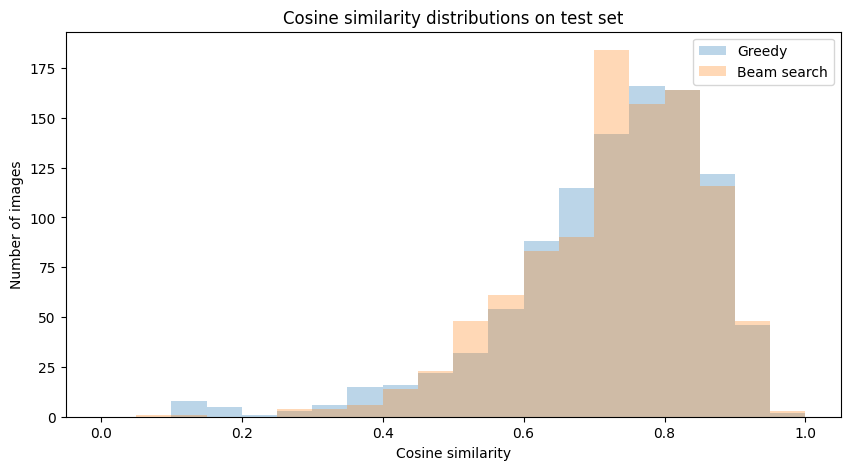

In [76]:
#plot histograms
plt.figure(figsize=(10,5))

bins = np.linspace(0, 1, 21)

plt.hist(cos_sim_greedy, bins=bins, alpha=0.3, label='Greedy')
plt.hist(cos_sim_beam_search, bins=bins, alpha=0.3, label='Beam search')
plt.xlabel('Cosine similarity')
plt.ylabel('Number of images')
plt.title('Cosine similarity distributions on test set')

plt.legend()
plt.show()

### 7.2 Cosine similarity examples (high and low scores)

In [77]:
#pick a suitable threshold where both greedy and beam search captions are very close to reference captions
threshold = 0.95

#get image ids corresponding to greedy cosine similarity score close to 1
high_greedy_ids = set(results[(results['caption_type'] == 'greedy') & (results['cos_similarity'] >= threshold)]['image_id'])

#get image ids corresponding to beam search cosine similarity score close to 1
high_beam_search_ids = set(results[(results['caption_type'] == 'beam_search') & (results['cos_similarity'] >= threshold)]['image_id'])

#find the intersection of the two sets
high_ids = list(high_greedy_ids.intersection(high_beam_search_ids))

#get one of these image ids
id_high_cos_sim = high_ids[0]

#get corresponding greedy caption
greedy_caption = results[(results['image_id'] == id_high_cos_sim) & (results['caption_type'] == 'greedy')]['caption'].item()

#get corresponding greedy cosine similarity score
greedy_cos_sim = results[(results['image_id'] == id_high_cos_sim) & (results['caption_type'] == 'greedy')]['cos_similarity'].item()

#get corresponding beam search caption
beam_search_caption = results[(results['image_id'] == id_high_cos_sim) & (results['caption_type'] == 'beam_search')]['caption'].item()

#get corresponding beam search cosine similarity score
beam_search_cos_sim = results[(results['image_id'] == id_high_cos_sim) & (results['caption_type'] == 'beam_search')]['cos_similarity'].item()

#get corresponding reference captions
reference_captions = results[(results['image_id'] == id_high_cos_sim) & (results['caption_type'] == 'reference')]['caption'].tolist()

print('Greedy predicted caption:', greedy_caption)
print(f'Greedy cosine similarity score: {greedy_cos_sim:.2f}\n')
print('Beam search predicted caption:', beam_search_caption)
print(f'Beam search cosine similarity score: {beam_search_cos_sim:.2f}\n')
print('Reference captions:')
for ref in reference_captions:
  print('-', ref)

Greedy predicted caption: a bathroom with a sink and a mirror
Greedy cosine similarity score: 0.97

Beam search predicted caption: a bathroom with a sink and a mirror
Beam search cosine similarity score: 0.97

Reference captions:
- a bathroom with a sink a mirror and a lampo
- a bathroom with a sink mirror and towel rack
- a white sink under a mirror and red walls
- a bathroom with red walls  a sink  and a table
- a bathroom painted red with a sink and wall light


In [78]:
#pick a suitable threshold where both greedy and beam search captions are very different from reference captions
threshold = 0.3

#get image ids corresponding to greedy cosine similarity score close to 0
low_greedy_ids = set(results[(results['caption_type'] == 'greedy') & (results['cos_similarity'] <= threshold)]['image_id'])

#get image ids corresponding to beam search cosine similarity score close to 0
low_beam_search_ids = set(results[(results['caption_type'] == 'beam_search') & (results['cos_similarity'] <= threshold)]['image_id'])

#find the intersection of the two sets
low_ids = list(low_greedy_ids.intersection(low_beam_search_ids))

#get one of these image ids
id_low_cos_sim = low_ids[0]

#get corresponding greedy caption
greedy_caption = results[(results['image_id'] == id_low_cos_sim) & (results['caption_type'] == 'greedy')]['caption'].item()

#get corresponding greedy cosine similarity score
greedy_cos_sim = results[(results['image_id'] == id_low_cos_sim) & (results['caption_type'] == 'greedy')]['cos_similarity'].item()

#get corresponding beam search caption
beam_search_caption = results[(results['image_id'] == id_low_cos_sim) & (results['caption_type'] == 'beam_search')]['caption'].item()

#get corresponding beam search cosine similarity score
beam_search_cos_sim = results[(results['image_id'] == id_low_cos_sim) & (results['caption_type'] == 'beam_search')]['cos_similarity'].item()

#get corresponding reference captions
reference_captions = results[(results['image_id'] == id_low_cos_sim) & (results['caption_type'] == 'reference')]['caption'].tolist()

print('Greedy predicted caption:', greedy_caption)
print(f'Greedy cosine similarity score: {greedy_cos_sim:.2f}\n')
print('Beam search predicted caption:', beam_search_caption)
print(f'Beam search cosine similarity score: {beam_search_cos_sim:.2f}\n')
print('Reference captions:')
for ref in reference_captions:
  print('-', ref)

Greedy predicted caption: a man is carrying a large tray of bananas
Greedy cosine similarity score: 0.29

Beam search predicted caption: a group of people that are sitting at a table
Beam search cosine similarity score: 0.29

Reference captions:
- people shopping in an open market for vegetables
- an open market full of people and piles of vegetables
- people are shopping at an open air produce market
- large piles of carrots and potatoes at a crowded outdoor market
- people shop for vegetables like carrots and potatoes at an open air market


## 8 Comparing BLEU and cosine similarity

### 8.1 Test set distribution of scores

In [4]:
#All necessary scores are stored in the results df.
results.head(10)

NameError: name 'results' is not defined

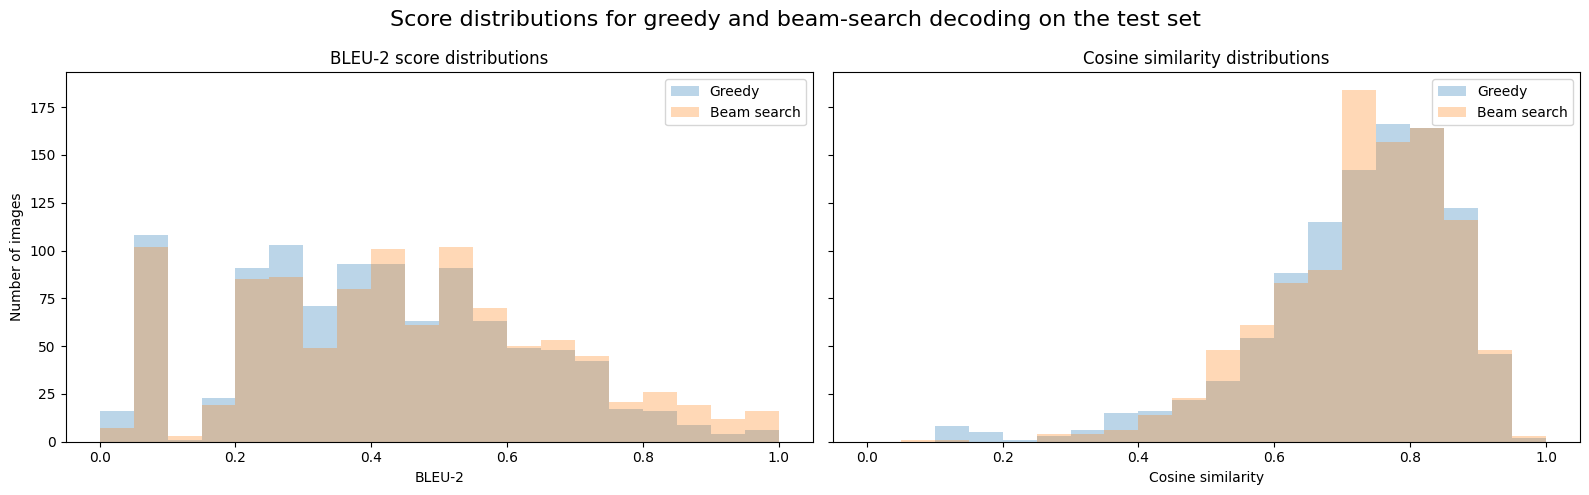

In [80]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

bins = np.linspace(0, 1, 21)

#BLEU-2
axs[0].hist(bleu2_greedy, bins=bins, alpha=0.3, label='Greedy')
axs[0].hist(bleu2_beam_search, bins=bins, alpha=0.3, label='Beam search')
axs[0].set_xlabel('BLEU-2')
axs[0].set_ylabel('Number of images')
axs[0].set_title('BLEU-2 score distributions')
axs[0].legend()

#cosine similarity
axs[1].hist(cos_sim_greedy, bins=bins, alpha=0.3, label='Greedy')
axs[1].hist(cos_sim_beam_search, bins=bins, alpha=0.3, label='Beam search')
axs[1].set_xlabel('Cosine similarity')
axs[1].set_title('Cosine similarity distributions')
axs[1].legend()

plt.suptitle('Score distributions for greedy and beam-search decoding on the test set', fontsize=16)
plt.tight_layout()
plt.show()

In [81]:
#BLEU-2 averages
bleu_ave_greedy = results[results['caption_type'] == 'greedy']['bleu2'].mean()
bleu_ave_beam_search = results[results['caption_type'] == 'beam_search']['bleu2'].mean()

#cosine similarity averages
cos_sim_greedy = results[results['caption_type'] == 'greedy']['cos_similarity'].mean()
cos_sim_beam_search = results[results['caption_type'] == 'beam_search']['cos_similarity'].mean()

#The cosine similarity scores are already in the range [0,1], but to take into account that in principle they could be in the range [-1,1], I rescale them
cos_sim_ave_greedy = ((cos_sim_greedy + 1)/2).mean()
cos_sim_ave_beam_search = ((cos_sim_beam_search + 1)/2).mean()

print('BLEU-2 score averages:')
print(f'Greedy decoding: {bleu_ave_greedy:.2f}')
print(f'Beam search decoding: {bleu_ave_beam_search:.2f} \n')

print('Cosine similarity score averages (after rescaling):')
print(f'Greedy decoding: {cos_sim_ave_greedy:.2f}')
print(f'Beam search decoding: {cos_sim_ave_beam_search:.2f}')

BLEU-2 score averages:
Greedy decoding: 0.41
Beam search decoding: 0.44 

Cosine similarity score averages (after rescaling):
Greedy decoding: 0.86
Beam search decoding: 0.86


**Discussion**

ADVANTAGES AND DISADVANTAGES

1. BLEU is a metric that evaluates the presence of consecutive matching words in the predicted and reference captions. As such, it checks if the two captions contain the exact same sequences of words. So, it is good for measuring exact word matching, but it is not suitable for semantic analysis (two synonym words would have a BLEU-1 score of 0).

2. Cosine similarity on the other hand focuses on semantics and not on exact words (indeed, it does not compare sequences of words but rather embedding vectors). Thus, this score is better for semantic text analysis compared with BLEU. However, cosine similarity is less sensitive to word ordering than BLEU, and this can result in sequences of words with different order having high cosine similarity scores, even if they are not similar.      

DIFFERENCES BETWEEN GREEDY AND BEAM-SEARCH DECODING UNDER THE TWO SCORES

1. The average BLEU-2 score increases by around 7% when using beam-search decoding with respect to greedy decoding (as I pointed out earlier, the average BLEU-3 score increases even more, by around 20%). This means that maintaining multiple candidate sequences possible at each step (beam search) results in overall more accurate captions. This makes sense, as larger sequences of words are evaluated at each step, so the BLEU-2 and BLEU-3 scores are likely to improve. On the other hand, picking the most likely word at each step (greedy) leads to less optimal captions, with the model sometimes falling into repetitive loops (which I have notices for some images), resulting in lower BLEU scores.

2. The cosine similarity does not seem to be affected by the decoding model, at least regarding its average value (slight variations can be seen in the histograms). This indicates that both decoding models are identifying the semantics of the captions (key objects/actions) to the same extent. This is consistent with the fact that cosine similarity is not so sensitive to word ordering, so the advantages brought about by beam search in the structure of the predicted captions do not affect this score.


### 8.2 Analysis of individual examples (similar and different scores)

In [82]:
#get image ids with similar BLEU-2 and cosine similarity scores for both approaches
thresh_1 = 0.4
thresh_2 = 0.45

greedy_ids = set(results[
    (results['caption_type'] == 'greedy') &
    (results['cos_similarity'] > thresh_1) &
    (results['cos_similarity'] < thresh_2) &
    (results['bleu2'] > thresh_1) &
    (results['bleu2'] < thresh_2)]
    ['image_id'])

beam_search_ids = set(results[
    (results['caption_type'] == 'beam_search') &
    (results['cos_similarity'] > thresh_1) &
    (results['cos_similarity'] < thresh_2) &
    (results['bleu2'] > thresh_1) &
    (results['bleu2'] < thresh_2)]
    ['image_id'])

#find the intersection of the two sets
ids = list(greedy_ids.intersection(beam_search_ids))

#get one of these image ids
selected_id = ids[0]

#get corresponding greedy caption
greedy_caption = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'greedy')]['caption'].item()

#get corresponding BLEU-2 score for greedy
greedy_bleu = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'greedy')]['bleu2'].item()

#get corresponding cosine similarity score for greedy
greedy_cos_sim = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'greedy')]['cos_similarity'].item()

#get corresponding beam search caption
beam_search_caption = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'beam_search')]['caption'].item()

#get corresponding BLEU-2 score for beam search
beam_search_bleu = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'beam_search')]['bleu2'].item()

#get corresponding cosine similarity score for beam search
beam_search_cos_sim = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'beam_search')]['cos_similarity'].item()

#get corresponding reference captions
reference_captions = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'reference')]['caption'].tolist()


print('Greedy predicted caption:', greedy_caption)
print(f'Greedy BLEU-2 score: {greedy_bleu:.2f}')
print(f'Greedy cosine similarity score: {greedy_cos_sim:.2f}\n')
print('Beam search predicted caption:', beam_search_caption)
print(f'Beam search BLEU-2 score: {beam_search_bleu:.2f}')
print(f'Beam search cosine similarity score: {beam_search_cos_sim:.2f}\n')
for ref in reference_captions:
  print('-', ref)

Greedy predicted caption: two plates of food on a table
Greedy BLEU-2 score: 0.40
Greedy cosine similarity score: 0.45

Beam search predicted caption: two plates of food on a table
Beam search BLEU-2 score: 0.40
Beam search cosine similarity score: 0.45

- a wooden table topped with two plates with sandwiches
- two plates with sandwiches on them and bowls of yogurt
- a plate with two sandwiches and a bowl of yogurt with grapes
- there are two plates with sandwiches and two bowls
- tray holding two bowls and two plates of sandwhiches


In [83]:
#get image ids with different BLEU-2 and cosine similarity scores for both approaches
thresh_1 = 0.2
thresh_2 = 0.6

greedy_ids = set(results[
    (results['caption_type'] == 'greedy') &
    (results['cos_similarity'] < thresh_1) &
    (results['bleu2'] < thresh_1)]
    ['image_id'])

beam_search_ids = set(results[
    (results['caption_type'] == 'beam_search') &
    (results['cos_similarity'] > thresh_2) &
    (results['bleu2'] > thresh_2)]
    ['image_id'])

#find the intersection of the two sets
ids = list(greedy_ids.intersection(beam_search_ids))

#get one of these image ids
selected_id = ids[0]

#get corresponding greedy caption
greedy_caption = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'greedy')]['caption'].item()

#get corresponding BLEU-2 score for greedy
greedy_bleu = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'greedy')]['bleu2'].item()

#get corresponding cosine similarity score for greedy
greedy_cos_sim = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'greedy')]['cos_similarity'].item()

#get corresponding beam search caption
beam_search_caption = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'beam_search')]['caption'].item()

#get corresponding BLEU-2 score for beam search
beam_search_bleu = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'beam_search')]['bleu2'].item()

#get corresponding cosine similarity score for beam search
beam_search_cos_sim = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'beam_search')]['cos_similarity'].item()

#get corresponding reference captions
reference_captions = results[(results['image_id'] == selected_id) & (results['caption_type'] == 'reference')]['caption'].tolist()


print('Greedy predicted caption:', greedy_caption)
print(f'Greedy BLEU-2 score: {greedy_bleu:.2f}')
print(f'Greedy cosine similarity score: {greedy_cos_sim:.2f}\n')
print('Beam search predicted caption:', beam_search_caption)
print(f'Beam search BLEU-2 score: {beam_search_bleu:.2f}')
print(f'Beam search cosine similarity score: {beam_search_cos_sim:.2f}\n')
for ref in reference_captions:
  print('-', ref)

Greedy predicted caption: a <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
Greedy BLEU-2 score: 0.03
Greedy cosine similarity score: 0.11

Beam search predicted caption: a group of people walking down a street
Beam search BLEU-2 score: 0.62
Beam search cosine similarity score: 0.73

- a group of people walking across a large sidewalk
- people crossing the street and walking on the sidewalks in front of buildings
- a man crossing a busy intersection near train tracks 
- a busy cross walk between some businesses and a bridge
- many people are seen on the streets of a city
